# mIEC Seurat Workflow - SCTransform and CCA integration

# 1. Load packages and time trakking



In [1]:
suppressPackageStartupMessages({
  library(Seurat)
  library(SeuratObject)
  library(tidyverse)
  library(data.table)
  library(Matrix)
  library(patchwork)
  library(pheatmap)
  library(clustree)
  library(SingleCellExperiment)
  library(scDblFinder)
  library(cluster)
  library(dplyr)
})

workflow_start <- Sys.time()
set.seed(1234)




# 2. Paths and output folders

In [89]:
DATASET <- "mIEC"
VERSION <- "seurat_noIntegration"

DATA_DIR <- "/CEPH/users/mtarzi/scRNA_sequencing_of_murine_intestinal_epithelial/data"

BASE_DIR <- "/CEPH/users/mtarzi/scRNA_sequencing_of_murine_intestinal_epithelial"
OUT_DIR <- file.path(BASE_DIR, "seurat_CCA_Integration")
TABLE_DIR <- file.path(OUT_DIR, "tables")
FIGURE_DIR <- file.path(OUT_DIR, "figures")
OBJECT_DIR <- file.path(OUT_DIR, "objects")
COMPARISON_DIR <- file.path(BASE_DIR, "seurat_workflow_comparison")

for (d in c(OUT_DIR, TABLE_DIR, FIGURE_DIR, OBJECT_DIR)) {
  dir.create(d, recursive = TRUE, showWarnings = FALSE)
}

# 3. Discover DGE text files and create dataset overview  
ach DGE file represents one sample. `CTRL_1` and `CTRL_2` belong to the CTRL condition, while `CD45` and `ITGAX` represent experimental conditions.

In [3]:
dge_files <- list.files(
  DATA_DIR,
  pattern = "^DGE_.*\\.txt$",
  full.names = TRUE
)

dge_files <- sort(dge_files)

cat("Number of DGE files found:", length(dge_files), "\n")
print(basename(dge_files))

Number of DGE files found: 4 
[1] "DGE_CD45.txt"   "DGE_CTRL_1.txt" "DGE_CTRL_2.txt" "DGE_ITGAX.txt" 


In [4]:
overview_rows <- lapply(dge_files, function(file) {
  file_name <- basename(file)
  sample <- file_name %>%
    str_replace("^DGE_", "") %>%
    str_replace("\\.txt$", "")
  
  header <- fread(file, nrows = 0)
  n_cells <- ncol(header) - 1
  n_genes <- length(readLines(file)) - 1
  
  condition <- sample %>%
    str_replace("_1$", "") %>%
    str_replace("_2$", "")
  
  data.frame(
    file = file_name,
    sample = sample,
    condition = condition,
    n_cells = n_cells,
    n_genes = n_genes,
    available_metadata = "sample, condition, original_barcode"
  )
})

dataset_overview <- bind_rows(overview_rows)

write.csv(
  dataset_overview,
  file.path(TABLE_DIR, "01_dataset_overview.csv"),
  row.names = FALSE
)

dataset_overview

file,sample,condition,n_cells,n_genes,available_metadata
<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
DGE_CD45.txt,CD45,CD45,769,14664,"sample, condition, original_barcode"
DGE_CTRL_1.txt,CTRL_1,CTRL,1474,18633,"sample, condition, original_barcode"
DGE_CTRL_2.txt,CTRL_2,CTRL,379,16834,"sample, condition, original_barcode"
DGE_ITGAX.txt,ITGAX,ITGAX,874,18114,"sample, condition, original_barcode"


# 4. Read DGE files and create Seurat objects
Seurat expects count matrices in **genes × cells** format

In [5]:
seurat_list <- list()

for (i in seq_len(nrow(dataset_overview))) {
  file_path <- file.path(DATA_DIR, dataset_overview$file[i])
  sample <- dataset_overview$sample[i]
  condition <- dataset_overview$condition[i]
  
  cat("Reading:", sample, "\n")
  dge <- fread(file_path)
  
  gene_col <- colnames(dge)[1]
  genes <- make.unique(as.character(dge[[gene_col]]))
  
  counts_df <- as.data.frame(dge[, -1, with = FALSE])
  original_barcodes <- colnames(counts_df)
  
  counts_mat <- as.matrix(counts_df)
  rownames(counts_mat) <- genes
  colnames(counts_mat) <- paste(sample, original_barcodes, sep = "_")
  
  counts_sparse <- Matrix(counts_mat, sparse = TRUE)
  
  obj <- CreateSeuratObject(
    counts = counts_sparse,
    project = sample,
    min.cells = 0,
    min.features = 0
  )
  
  obj$sample <- sample
  obj$condition <- condition
  obj$original_barcode <- original_barcodes
  
  seurat_list[[sample]] <- obj
  
  print(obj)
}

Reading: CD45 
An object of class Seurat 
14664 features across 769 samples within 1 assay 
Active assay: RNA (14664 features, 0 variable features)
 1 layer present: counts
Reading: CTRL_1 
An object of class Seurat 
18633 features across 1474 samples within 1 assay 
Active assay: RNA (18633 features, 0 variable features)
 1 layer present: counts
Reading: CTRL_2 
An object of class Seurat 
16834 features across 379 samples within 1 assay 
Active assay: RNA (16834 features, 0 variable features)
 1 layer present: counts
Reading: ITGAX 
An object of class Seurat 
18114 features across 874 samples within 1 assay 
Active assay: RNA (18114 features, 0 variable features)
 1 layer present: counts



# 5. Merge all samples

In [6]:
seurat_obj <- merge(
  x = seurat_list[[1]],
  y = seurat_list[-1],
  add.cell.ids = names(seurat_list),
  project = "mIEC_noIntegration"
)

seurat_obj

table(seurat_obj$sample)
table(seurat_obj$condition)

An object of class Seurat 
21925 features across 3496 samples within 1 assay 
Active assay: RNA (21925 features, 0 variable features)
 4 layers present: counts.CD45, counts.CTRL_1, counts.CTRL_2, counts.ITGAX


  CD45 CTRL_1 CTRL_2  ITGAX 
   769   1474    379    874 


 CD45  CTRL ITGAX 
  769  1853   874 

In [7]:
saveRDS(
  seurat_obj,
  file.path(OBJECT_DIR, "mIEC_seurat_noIntegration_prefilter_combined.rds")
)


# 6. Add mitochondrial and ribosomal genes    


In [8]:
seurat_obj[["percent.mt"]] <- PercentageFeatureSet(
  seurat_obj,
  pattern = "^mt-"
)

seurat_obj[["percent.rps"]] <- PercentageFeatureSet(
  seurat_obj,
  pattern = "^Rps"
)

seurat_obj[["percent.rpl"]] <- PercentageFeatureSet(
  seurat_obj,
  pattern = "^Rpl"
)

# Check summaries

summary(seurat_obj$percent.mt)
summary(seurat_obj$percent.rps)
summary(seurat_obj$percent.rpl)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
 0.0000  0.4895  1.2124  2.2288  2.7951 76.3158       2 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
 0.0000  0.5169  1.2274  2.0397  3.2680 13.5135       2 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
 0.0000  0.6614  1.5852  2.6339  4.2051 14.7929       2 

### Remove zero-count cells that produced NaN QC percentages

In [9]:
cells_before_zero_removal <- ncol(seurat_obj)

seurat_obj <- subset(
  seurat_obj,
  subset =
    nCount_RNA > 0 &
    nFeature_RNA > 0 &
    !is.na(percent.mt) &
    !is.na(percent.rps) &
    !is.na(percent.rpl)
)

cells_after_zero_removal <- ncol(seurat_obj)

cat("Cells before removing zero-count/NaN cells:", cells_before_zero_removal, "\n")
cat("Cells after removing zero-count/NaN cells:", cells_after_zero_removal, "\n")
cat("Cells removed:", cells_before_zero_removal - cells_after_zero_removal, "\n")

# checks
summary(seurat_obj$percent.mt)
summary(seurat_obj$percent.rps)
summary(seurat_obj$percent.rpl)

Cells before removing zero-count/NaN cells: 3496 
Cells after removing zero-count/NaN cells: 3494 
Cells removed: 2 


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.4895  1.2124  2.2288  2.7951 76.3158 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.5169  1.2274  2.0397  3.2680 13.5135 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.6614  1.5852  2.6339  4.2051 14.7929 


# 7. QC before filtering

In [10]:
QC_before_filtering <- data.frame(
  n_cells_total = ncol(seurat_obj),
  n_genes_total = nrow(seurat_obj),
  n_samples = length(unique(seurat_obj$sample)),
  samples = paste(unique(seurat_obj$sample), collapse = ", "),
  conditions = paste(unique(seurat_obj$condition), collapse = ", "),
  n_mt_genes = sum(grepl("^mt-", rownames(seurat_obj))),
  n_rps_genes = sum(grepl("^Rps", rownames(seurat_obj))),
  n_rpl_genes = sum(grepl("^Rpl", rownames(seurat_obj))),
  median_counts_per_cell = median(seurat_obj$nCount_RNA, na.rm = TRUE),
  median_genes_per_cell = median(seurat_obj$nFeature_RNA, na.rm = TRUE),
  median_pct_mt = median(seurat_obj$percent.mt, na.rm = TRUE),
  median_pct_rps = median(seurat_obj$percent.rps, na.rm = TRUE),
  median_pct_rpl = median(seurat_obj$percent.rpl, na.rm = TRUE)
)

write.csv(
  QC_before_filtering,
  file.path(TABLE_DIR, "mIEC_seurat_QC_before_filtering.csv"),
  row.names = FALSE
)

QC_before_filtering

n_cells_total,n_genes_total,n_samples,samples,conditions,n_mt_genes,n_rps_genes,n_rpl_genes,median_counts_per_cell,median_genes_per_cell,median_pct_mt,median_pct_rps,median_pct_rpl
<dbl>,<dbl>,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3494,21925,4,"CD45, CTRL_1, CTRL_2, ITGAX","CD45, CTRL, ITGAX",11,44,56,973,652,1.212366,1.2274,1.585208


Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


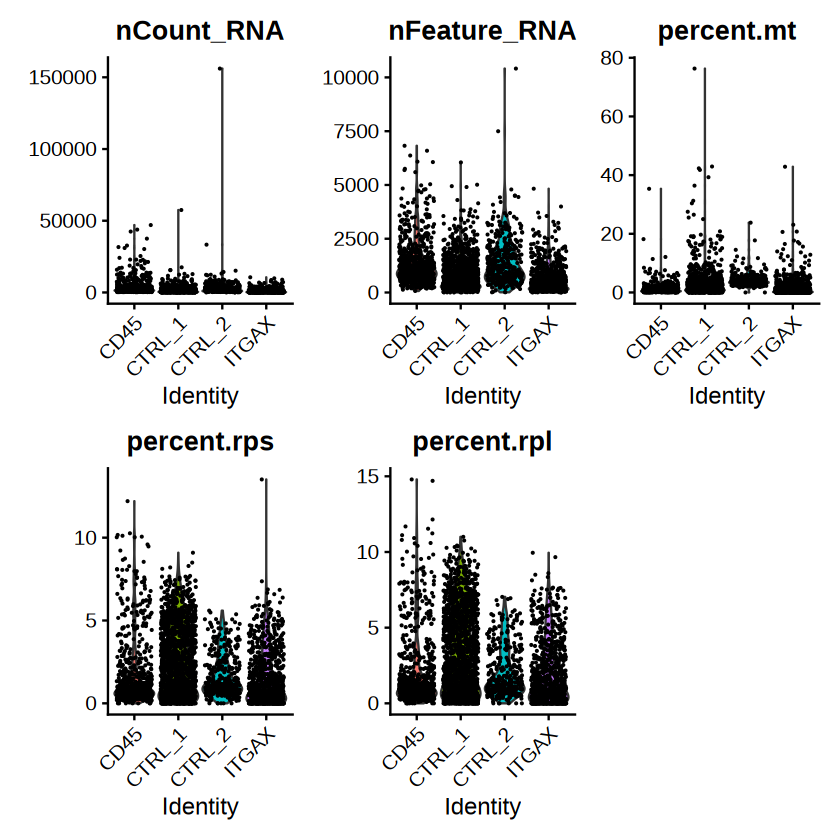

In [11]:
p1 <- VlnPlot(seurat_obj, 
              features = c("nCount_RNA", "nFeature_RNA", "percent.mt", "percent.rps", "percent.rpl"),
              group.by = "sample", 
              ncol= 3,
              pt.size = 0.1)



ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_QC_before_filtering_violin.png"),
  plot = p1,
  width = 14,
  height = 12,
  dpi = 300
)
p1

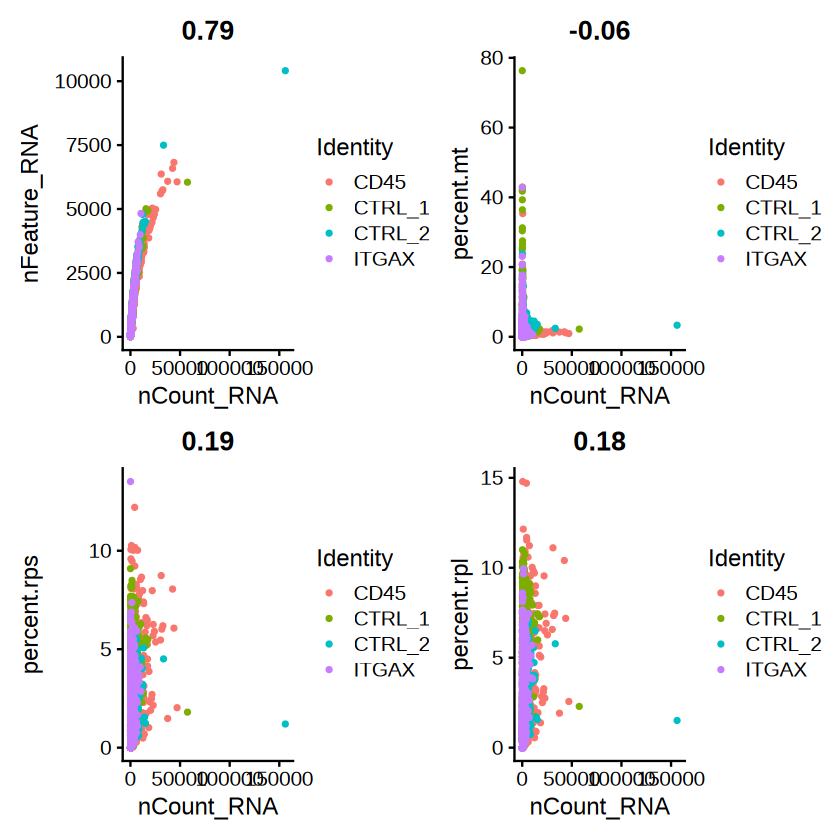

In [12]:
p_counts_features <- FeatureScatter(seurat_obj, feature1 = "nCount_RNA", feature2 = "nFeature_RNA", group.by = "sample")
p_counts_mt <- FeatureScatter(seurat_obj, feature1 = "nCount_RNA", feature2 = "percent.mt", group.by = "sample")
p_counts_rps <- FeatureScatter(seurat_obj, feature1 = "nCount_RNA",feature2 = "percent.rps", group.by = "sample")
p_counts_rpl <- FeatureScatter(seurat_obj, feature1 = "nCount_RNA",feature2 = "percent.rpl", group.by = "sample")

qc_scatter <- (p_counts_features | p_counts_mt )/
              (p_counts_rps |  p_counts_rpl)
qc_scatter

ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_QC_before_filtering_scatter.png"),
  plot = qc_scatter,
  width = 14,
  height = 10,
  dpi = 300
)


# 8. Filter cells and genes

In [13]:
MIN_GENES_PER_CELL <- 200
MAX_GENES_PER_CELL <- 5000
MAX_MT_PERCENT <- 5
MIN_CELLS_PER_GENE <- 3


cells_before_filtering <- ncol(seurat_obj)
genes_before_filtering <- nrow(seurat_obj)

cat("Before filtering:\n")
cat("Cells:", cells_before_filtering, "\n")
cat("Genes:", genes_before_filtering, "\n")


# Cell filtering
seurat_filtered <- subset(
  seurat_obj,
  subset =
    nFeature_RNA >= MIN_GENES_PER_CELL &
    nFeature_RNA <= MAX_GENES_PER_CELL &
    percent.mt <= MAX_MT_PERCENT 
)

cat("After cell filtering:\n")
cat("Cells:", ncol(seurat_filtered), "\n")
cat("Genes:", nrow(seurat_filtered), "\n")


# Join layers for Seurat v5 compatibility
seurat_filtered <- JoinLayers(
  object = seurat_filtered,
  assay = "RNA"
)




Before filtering:
Cells: 3494 
Genes: 21925 
After cell filtering:
Cells: 2741 
Genes: 21925 


In [14]:
# Gene filtering: keep genes detected in at least 3 cells
counts_matrix <- GetAssayData(
  seurat_filtered,
  assay = "RNA",
  layer = "counts"
)

genes_keep <- rowSums(counts_matrix > 0) >= MIN_CELLS_PER_GENE

seurat_filtered <- subset(
  seurat_filtered,
  features = names(genes_keep[genes_keep])
)

cat("After gene filtering:\n")
cat("Cells:", ncol(seurat_filtered), "\n")
cat("Genes:", nrow(seurat_filtered), "\n")


After gene filtering:
Cells: 2741 
Genes: 17464 


In [15]:
# Filtering summary table

filtering_summary <- data.frame(
  filtering_step = "QC_filtering",
  min_genes_per_cell = MIN_GENES_PER_CELL,
  max_genes_per_cell = MAX_GENES_PER_CELL,
  max_mt_percent = MAX_MT_PERCENT,
  min_cells_per_gene = MIN_CELLS_PER_GENE,
  cells_before_filtering = cells_before_filtering,
  cells_after_filtering = ncol(seurat_filtered),
  cells_removed = cells_before_filtering - ncol(seurat_filtered),
  genes_before_filtering = genes_before_filtering,
  genes_after_filtering = nrow(seurat_filtered),
  genes_removed = genes_before_filtering - nrow(seurat_filtered)
)

write.csv(
  filtering_summary,
  file.path(TABLE_DIR, "mIEC_seurat_filtering_summary.csv"),
  row.names = FALSE
)

filtering_summary

filtering_step,min_genes_per_cell,max_genes_per_cell,max_mt_percent,min_cells_per_gene,cells_before_filtering,cells_after_filtering,cells_removed,genes_before_filtering,genes_after_filtering,genes_removed
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
QC_filtering,200,5000,5,3,3494,2741,753,21925,17464,4461


In [16]:
# Filtering summary by sample

cells_per_sample_before <- as.data.frame(table(seurat_obj$sample))
colnames(cells_per_sample_before) <- c("sample", "before_filtering")

cells_per_sample_after <- as.data.frame(table(seurat_filtered$sample))
colnames(cells_per_sample_after) <- c("sample", "after_filtering")

sample_filtering_summary <- merge(
  cells_per_sample_before,
  cells_per_sample_after,
  by = "sample",
  all = TRUE
)

sample_filtering_summary[is.na(sample_filtering_summary)] <- 0

sample_filtering_summary$removed <- (
  sample_filtering_summary$before_filtering -
  sample_filtering_summary$after_filtering
)

sample_filtering_summary$percent_removed <- (
  sample_filtering_summary$removed /
  sample_filtering_summary$before_filtering * 100
)

write.csv(
  sample_filtering_summary,
  file.path(TABLE_DIR, "mIEC_seurat_filtering_summary_by_sample.csv"),
  row.names = FALSE
)

sample_filtering_summary

sample,before_filtering,after_filtering,removed,percent_removed
<fct>,<int>,<int>,<int>,<dbl>
CD45,769,730,39,5.071521
CTRL_1,1474,1147,327,22.184532
CTRL_2,379,304,75,19.788918
ITGAX,872,560,312,35.779817



# 9. QC after filtering

In [17]:
qc_after <- data.frame(
  n_cells_total = ncol(seurat_filtered),
  n_genes_total = nrow(seurat_filtered),
  n_samples = length(unique(seurat_filtered$sample)),
  samples = paste(unique(seurat_filtered$sample), collapse = ", "),
  conditions = paste(unique(seurat_filtered$condition), collapse = ", "),
  n_mt_genes = sum(grepl("^mt-", rownames(seurat_obj))),
  n_rps_genes = sum(grepl("^Rps", rownames(seurat_obj))),
  n_rpl_genes = sum(grepl("^Rpl", rownames(seurat_obj))),
  median_counts_per_cell = median(seurat_filtered$nCount_RNA),
  median_genes_per_cell = median(seurat_filtered$nFeature_RNA),
  median_pct_mt = median(seurat_filtered$percent.mt),
  median_pct_rps = median(seurat_filtered$percent.rps),
  median_pct_rpl = median(seurat_filtered$percent.rpl)
)

write.csv(qc_after, file.path(TABLE_DIR, "04_QC_after_filtering.csv"), row.names = FALSE)
qc_after


n_cells_total,n_genes_total,n_samples,samples,conditions,n_mt_genes,n_rps_genes,n_rpl_genes,median_counts_per_cell,median_genes_per_cell,median_pct_mt,median_pct_rps,median_pct_rpl
<dbl>,<dbl>,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
2741,17464,4,"CD45, CTRL_1, CTRL_2, ITGAX","CD45, CTRL, ITGAX",11,44,56,1312,833,1.081917,1.485536,1.898734


Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


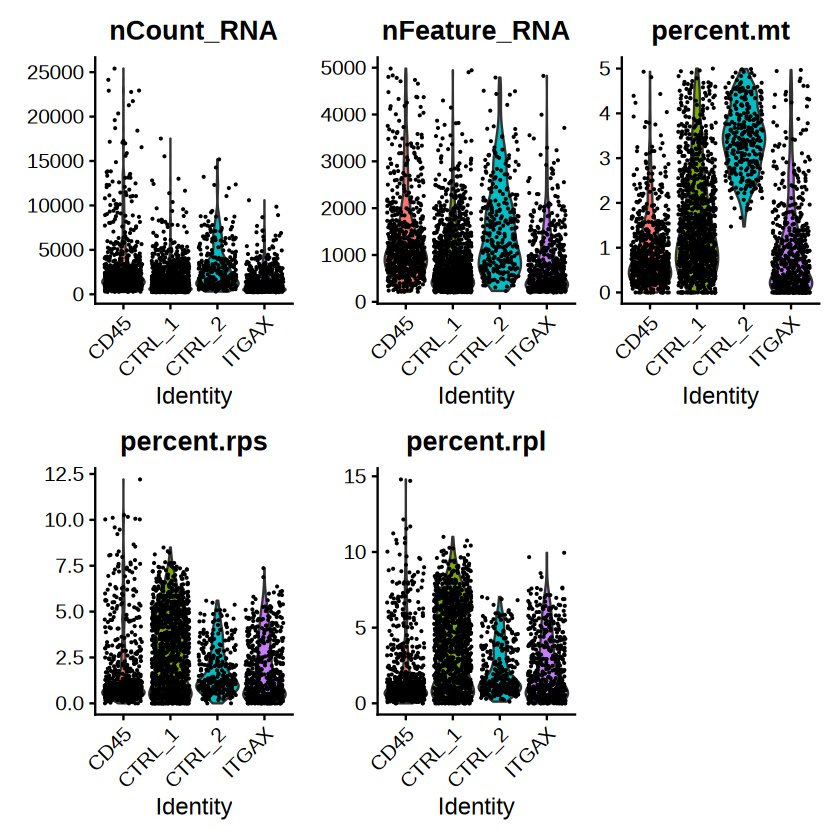

In [18]:
p1 <- VlnPlot(seurat_filtered, 
              features = c("nCount_RNA", "nFeature_RNA", "percent.mt", "percent.rps", "percent.rpl"),
              group.by = "sample", 
              ncol= 3,
              pt.size = 0.1)



ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_QC_after_filtering_violin.png"),
  plot = p1,
  width = 14,
  height = 12,
  dpi = 300
)
p1

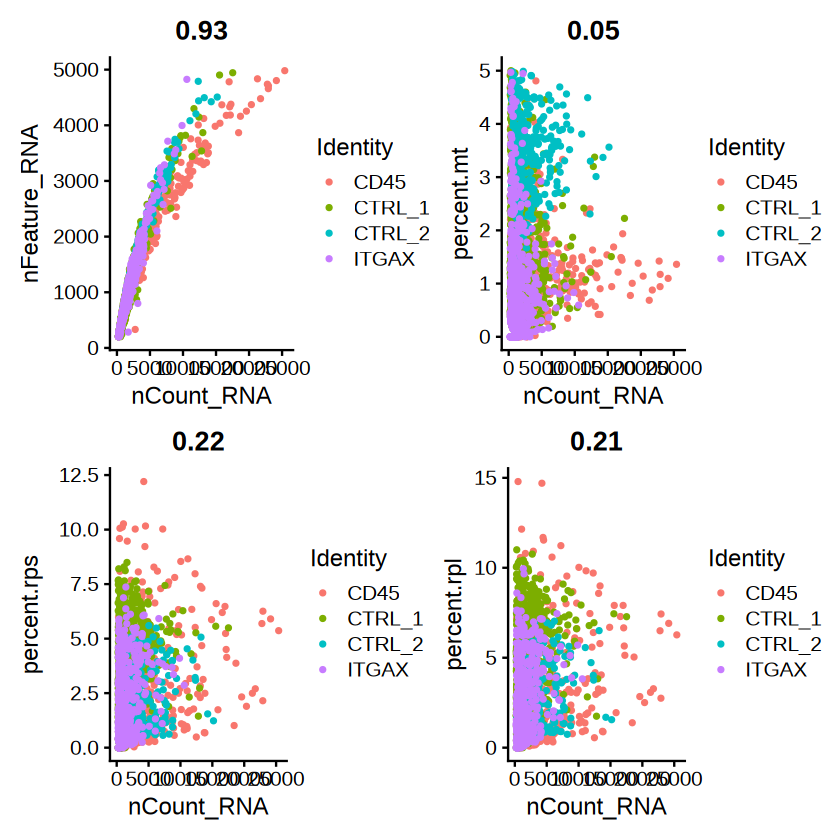

In [19]:
p_counts_features <- FeatureScatter(seurat_filtered, feature1 = "nCount_RNA", feature2 = "nFeature_RNA", group.by = "sample")
p_counts_mt <- FeatureScatter(seurat_filtered, feature1 = "nCount_RNA", feature2 = "percent.mt", group.by = "sample")
p_counts_rps <- FeatureScatter(seurat_filtered, feature1 = "nCount_RNA",feature2 = "percent.rps", group.by = "sample")
p_counts_rpl <- FeatureScatter(seurat_filtered, feature1 = "nCount_RNA",feature2 = "percent.rpl", group.by = "sample")

qc_scatter <- (p_counts_features | p_counts_mt )/
              (p_counts_rps |  p_counts_rpl)
qc_scatter

ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_QC_after_filtering_scatter.png"),
  plot = qc_scatter,
  width = 14,
  height = 10,
  dpi = 300
)




# 10. Doublet detection with scDblFinder

In [20]:
suppressWarnings({
    sce <- as.SingleCellExperiment(seurat_filtered)
    sce <- scDblFinder(sce, samples = sce$sample)
})

seurat_filtered$doublet_score <- sce$scDblFinder.score
seurat_filtered$predicted_doublet <- sce$scDblFinder.class == "doublet"

doublet_summary <- data.frame(
  category = c("singlet", "doublet"),
  n_cells = c(
    sum(!seurat_filtered$predicted_doublet),
    sum(seurat_filtered$predicted_doublet)
  )
)

write.csv(doublet_summary, file.path(TABLE_DIR, "05_doublet_summary.csv"), row.names = FALSE)
doublet_summary

cat("Before doublet removal:", ncol(seurat_filtered), "cells\n")
seurat_filtered <- subset(seurat_filtered, subset = predicted_doublet == FALSE)
cat("After doublet removal:", ncol(seurat_filtered), "cells\n")

category,n_cells
<chr>,<int>
singlet,2656
doublet,85


Before doublet removal: 2741 cells
After doublet removal: 2656 cells


In [21]:
saveRDS(
  seurat_filtered,
  file.path(OBJECT_DIR, "mIEC_seurat_filtered_doublet_removed.rds")
)

# 11. Integration with SCTransform and CCA

In [22]:
# Split filtered object by sample

seurat_list <- SplitObject(
  seurat_filtered,
  split.by = "sample"
)

In [23]:
# SCTransform normalization per sample
seurat_list <- lapply(
  seurat_list,
  function(x) {
    suppressWarnings({
      SCTransform(
        x,
        vars.to.regress = "percent.mt",
        verbose = FALSE
      )
    })
  }
)

`vst.flavor` is set to 'v2' but could not find glmGamPoi installed.
Please install the glmGamPoi package for much faster estimation.
--------------------------------------------
install.packages('BiocManager')
BiocManager::install('glmGamPoi')
--------------------------------------------
Falling back to native (slower) implementation.


`vst.flavor` is set to 'v2' but could not find glmGamPoi installed.
Please install the glmGamPoi package for much faster estimation.
--------------------------------------------
install.packages('BiocManager')
BiocManager::install('glmGamPoi')
--------------------------------------------
Falling back to native (slower) implementation.


`vst.flavor` is set to 'v2' but could not find glmGamPoi installed.
Please install the glmGamPoi package for much faster estimation.
--------------------------------------------
install.packages('BiocManager')
BiocManager::install('glmGamPoi')
--------------------------------------------
Falling back to native (slower) i

In [24]:
# Select integration features - alternative to HVGs

integration_features <- SelectIntegrationFeatures(
  object.list = seurat_list,
  nfeatures = 2000
)

In [25]:
# Prepare objects for SCT integration

seurat_list <- PrepSCTIntegration(
  object.list = seurat_list,
  anchor.features = integration_features
)

In [26]:
# Find integration anchors using CCA

integration_anchors <- FindIntegrationAnchors(
  object.list = seurat_list,
  normalization.method = "SCT",
  anchor.features = integration_features,
  reduction = "cca",
  dims = 1:30
)

Finding all pairwise anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 2839 anchors

Filtering anchors

	Retained 1814 anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 1339 anchors

Filtering anchors

	Retained 1267 anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 1437 anchors

Filtering anchors

	Retained 1393 anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 2153 anchors

Filtering anchors

	Retained 1656 anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 2320 anchors

Filtering anchors

	Retained 2112 anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 1350 anchors

Filtering anchors

	Retained 1105 anchors



In [27]:
# Integrated data assay

seurat_integrated <- IntegrateData(
  anchorset = integration_anchors,
  normalization.method = "SCT",
   k.weight = 70   # by default: dims = 1:30
)

[1] 1


Warning message:
“Different cells and/or features from existing assay SCT”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”


[1] 2


Warning message:
“Different cells and/or features from existing assay SCT”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”


[1] 3


Warning message:
“Different cells and/or features from existing assay SCT”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”


[1] 4


Warning message:
“Different cells and/or features from existing assay SCT”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Merging dataset 3 into 2

Extracting anchors for merged samples

Finding integration vectors

Finding integration vector weights

Integrating data

Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Merging dataset 4 into 2 3

Extracting anchors for merged samples

Finding integration vectors

Finding integration vector weights

Integrating data

Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Merging dataset 1 into 2 3 4

Extracting anchors for merged samples

Finding integration vectors

Finding integration vector weights

Integrating data

Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Assay integrated changing from Assay to SCTAssay”
Warning message:
“Layer counts isn't present in the assay object; returning NUL

## Set integrated assay as default

In [28]:
DefaultAssay(seurat_integrated) <- "integrated"


# 12. Scaling and PCA

In [29]:
seurat_integrated <- ScaleData(
  seurat_integrated,
  features = VariableFeatures(seurat_integrated)
)

N_PCS <- 100
seurat_integrated <- RunPCA(
  seurat_integrated,
  features = VariableFeatures(seurat_integrated),
  npcs = N_PCS
)

Centering and scaling data matrix

PC_ 1 
Positive:  Apoa1, Krt20, Apoa4, Fabp2, Rbp2, Anpep, Guca2b, Cyp3a13, Apoc2, Spink1 
	   Ace2, Slc5a1, Mttp, Crip1, Muc13, Aldob, Sis, Tm4sf4, Prap1, Smim24 
	   Malat1, Creb3l3, Fabp1, 2200002D01Rik, Tm4sf5, Muc3, Gda, Mep1b, Adh6a, Clec2h 
Negative:  Ptma, Ncl, Npm1, Rps19, Rps12, Rps18, Hmgb1, Hsp90ab1, Rps2, Rpl13 
	   Rplp0, Pabpc1, Rpl14, Rps14, Rpl3, Rpl13a, Rpl22, Rpl4, Serbp1, Rps8 
	   Rpl35, Rps9, Rps23, Rpl37, Rps3, Rpl37a, Rpl41, Rpl32, Set, Hspd1 
PC_ 2 
Positive:  Reg3b, Reg3g, Fabp1, Rbp2, Aldob, Ccl25, Fabp2, Gsta1, Ckmt1, Prdx1 
	   Plac8, Guca2b, Slc25a5, Dbi, Sis, Mt1, Atp1a1, Mttp, Me2, Smim24 
	   Apoa1, Anpep, Mgst1, Cyp4f14, Enpep, Slc5a1, Maoa, Acsl5, Spink1, Adh1 
Negative:  Tff3, Fcgbp, Zg16, Muc2, Clca1, Cldn4, Agr2, Fer1l6, Sytl2, Malat1 
	   Tm4sf4, Bcas1, S100a6, Spink4, Ido1, 2610035D17Rik, Neat1, Rab27a, Rab27b, Mllt3 
	   Atp2a3, Gm609, Srgap1, Defa24, Clic4, Hepacam2, 5330417C22Rik, Gcnt3, Krt18, Slc12a8 
PC_ 3

In [30]:
pca_stdev <- seurat_integrated[["pca"]]@stdev
pca_variance <- pca_stdev^2
pca_variance_ratio <- pca_variance / sum(pca_variance)
pca_variance_percent <- pca_variance_ratio * 100
cumulative_variance_percent <- cumsum(pca_variance_percent)
pcs <- seq_along(pca_variance_percent)

pca_variance_table <- data.frame(
  PC = pcs,
  variance_ratio = pca_variance_ratio,
  variance_percent = pca_variance_percent,
  cumulative_variance_percent = cumulative_variance_percent
)

write.csv(pca_variance_table, file.path(TABLE_DIR, "07_mIEC_seurat_CAA_Integration_PCA_variance_table.csv"), row.names = FALSE)
head(pca_variance_table, 20)

,PC,variance_ratio,variance_percent,cumulative_variance_percent
,<int>,<dbl>,<dbl>,<dbl>
1,1,0.162900089,16.2900089,16.29001
2,2,0.081284964,8.1284964,24.41851
3,3,0.059211500,5.9211500,30.33966
4,4,0.031987304,3.1987304,33.53839
5,5,0.025666272,2.5666272,36.10501
6,6,0.015823172,1.5823172,37.68733
7,7,0.013833930,1.3833930,39.07072
8,8,0.012998632,1.2998632,40.37059
9,9,0.011945470,1.1945470,41.56513


### Calculate PC Range and Select PCs  manually

In [31]:
pca_stdev <- seurat_integrated@reductions$pca@stdev

pct <- (pca_stdev^2) / sum(pca_stdev^2) * 100
cum <- cumsum(pct)

# Criterion 1:
# first PC where cumulative variance is above 90%
# and individual PC contribution is below 5%
co1 <- which(cum > 90 & pct < 5)[1]

# Criterion 2:
# last major drop in explained variance between consecutive PCs
co2 <- sort(
  which((pct[1:(length(pct) - 1)] - pct[2:length(pct)]) > 0.01),
  decreasing = TRUE
)[1] + 1

# Recommended range
pc_min <- min(co1, co2, na.rm = TRUE)
pc_max <- max(co1, co2, na.rm = TRUE)

cat("Criterion 1 PC:", co1, "\n")
cat("Criterion 2 PC:", co2, "\n")
cat("Recommended PC range:", pc_min, "to", pc_max, "\n")

Criterion 1 PC: 83 
Criterion 2 PC: 20 
Recommended PC range: 20 to 83 


### PCA elbow plot with selected PCs


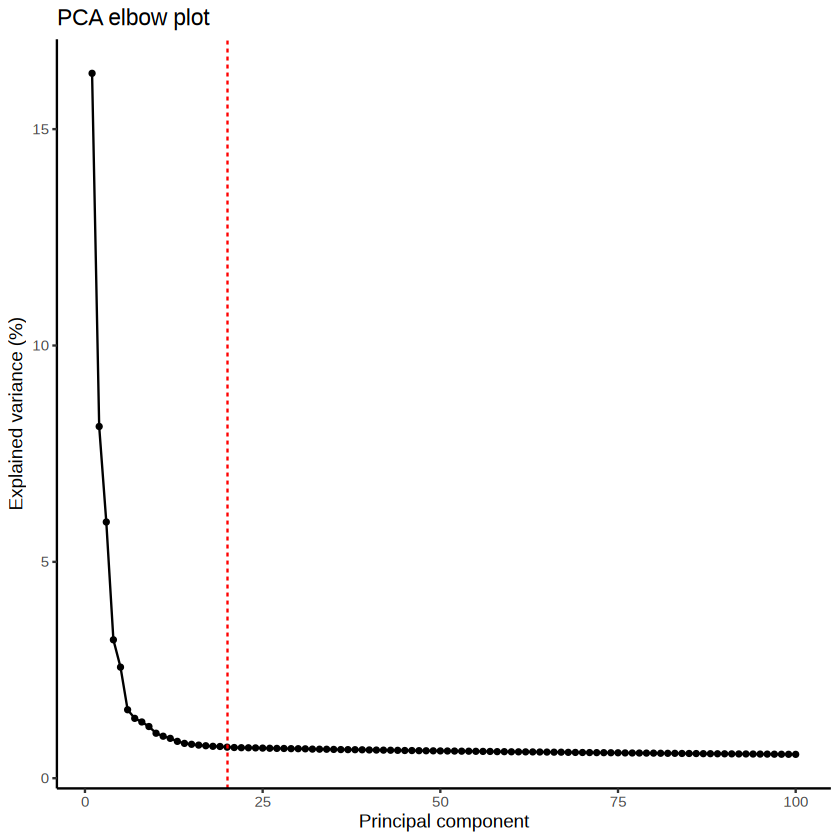

In [32]:
SELECTED_PCS <- 20

elbow_df <- pca_variance_table
p_elbow <- ggplot(elbow_df, aes(x = PC, y = variance_percent)) +
  geom_line() +
  geom_point(size = 1) +
  geom_vline(xintercept = SELECTED_PCS, linetype = "dashed", color = "red") +
  theme_classic() +
  labs(
    title = "PCA elbow plot",
    x = "Principal component",
    y = "Explained variance (%)"
  )

p_elbow

ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_integrated_PCA_elbow_selected_PCs.png"),
  plot = p_elbow,
  width = 8,
  height = 5,
  dpi = 300
)


# 13. Neighbors, UMAP and t-SNE without integration   


In [33]:
seurat_integrated <- FindNeighbors(
  seurat_integrated,
  dims = 1:SELECTED_PCS
)

seurat_integrated <- RunUMAP(
  seurat_integrated,
  dims = 1:SELECTED_PCS
)

seurat_integrated <- RunTSNE(
  seurat_integrated,
  dims = 1:SELECTED_PCS
)

Computing nearest neighbor graph

Computing SNN

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
07:18:41 UMAP embedding parameters a = 0.9922 b = 1.112

07:18:41 Read 2656 rows and found 20 numeric columns

07:18:41 Using Annoy for neighbor search, n_neighbors = 30

07:18:41 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

07:18:41 Writing NN index file to temp file /tmp/Rtmpk8zNEM/file6295287ca9af

07:18:41 Searching Annoy index using 1 thread, search_k = 3000

07:18:42 Annoy recall = 100%

07:18:43 Commencing smooth kNN distance cali

### UMAP   


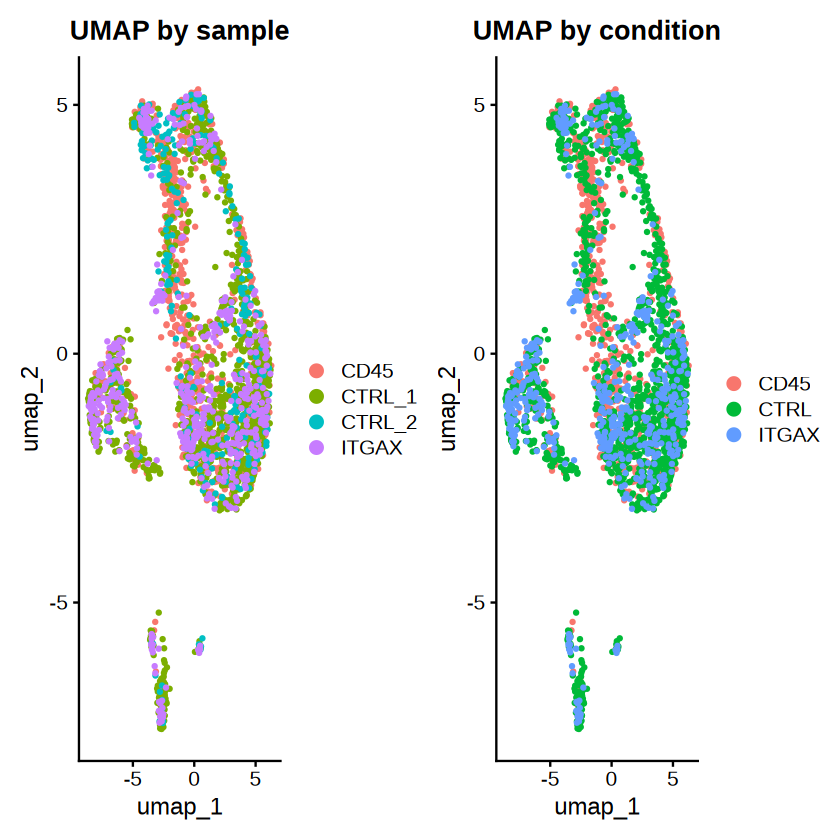

In [34]:
p_umap_sample <- DimPlot(seurat_integrated, reduction = "umap", group.by = "sample") + ggtitle("UMAP by sample")
p_umap_condition <- DimPlot(seurat_integrated, reduction = "umap", group.by = "condition") + ggtitle("UMAP by condition")

p_umap_meta <- p_umap_sample | p_umap_condition
p_umap_meta

ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_withIntegration_UMAP_sample_condition.png"),
  plot = p_umap_meta,
  width = 12,
  height = 5,
  dpi = 300
)



# 14. Clustering across resolutions

In [35]:
# Clustering across multiple resolutions using Louvain and Leiden

resolutions <- seq(0.1, 1.9, by = 0.1)

# Louvain clustering: algorithm 1
seurat_integrated <- FindClusters(
  seurat_integrated,
  resolution = resolutions,
  algorithm = 1,
  cluster.name = paste0("louvain_res_", resolutions)
)

# Leiden clustering: algorithm 4
seurat_integrated <- FindClusters(
  seurat_integrated,
  resolution = resolutions,
  algorithm = 4,
  cluster.name = paste0("leiden_res_", resolutions)
)


Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 2656
Number of edges: 113147

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9337
Number of communities: 5
Elapsed time: 0 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 2656
Number of edges: 113147

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9056
Number of communities: 6
Elapsed time: 0 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 2656
Number of edges: 113147

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8814
Number of communities: 7
Elapsed time: 0 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 2656
Number of edges: 113147

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8607
Number of communities: 9
Elapsed time: 0 seconds
Modularity Optimizer

Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
“`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1.”
Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
“`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1.”
Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
“`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1.”
Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
“`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1.”
Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
“`random.seed` must be greater than 0 for leiden clu

In [36]:
# Create clustering summary with Louvain and Leiden side by side

louvain_columns <- grep("^louvain_res_", colnames(seurat_integrated@meta.data), value = TRUE)
leiden_columns <- grep("^leiden_res_", colnames(seurat_integrated@meta.data), value = TRUE)

louvain_summary <- lapply(louvain_columns, function(col) {
  data.frame(
    resolution = as.numeric(gsub("louvain_res_", "", col)),
    louvain_column = col,
    louvain_n_clusters = length(unique(seurat_integrated@meta.data[[col]]))
  )
}) %>% bind_rows()

leiden_summary <- lapply(leiden_columns, function(col) {
  data.frame(
    resolution = as.numeric(gsub("leiden_res_", "", col)),
    leiden_column = col,
    leiden_n_clusters = length(unique(seurat_integrated@meta.data[[col]]))
  )
}) %>% bind_rows()

clustering_summary <- full_join(
  louvain_summary,
  leiden_summary,
  by = "resolution"
) %>%
  arrange(resolution)

write.csv(
  clustering_summary,
  file.path(TABLE_DIR, "08_sseurat_withIntegration_clustering_summary_louvain_leiden.csv"),
  row.names = FALSE
)

clustering_summary

resolution,louvain_column,louvain_n_clusters,leiden_column,leiden_n_clusters
<dbl>,<chr>,<int>,<chr>,<int>
0.1,louvain_res_0.1,5,leiden_res_0.1,5
0.2,louvain_res_0.2,6,leiden_res_0.2,6
0.3,louvain_res_0.3,7,leiden_res_0.3,5
0.4,louvain_res_0.4,9,leiden_res_0.4,7
0.5,louvain_res_0.5,9,leiden_res_0.5,7
0.6,louvain_res_0.6,9,leiden_res_0.6,8
0.7,louvain_res_0.7,10,leiden_res_0.7,9
0.8,louvain_res_0.8,12,leiden_res_0.8,9
0.9,louvain_res_0.9,13,leiden_res_0.9,11


### Louvain clustree

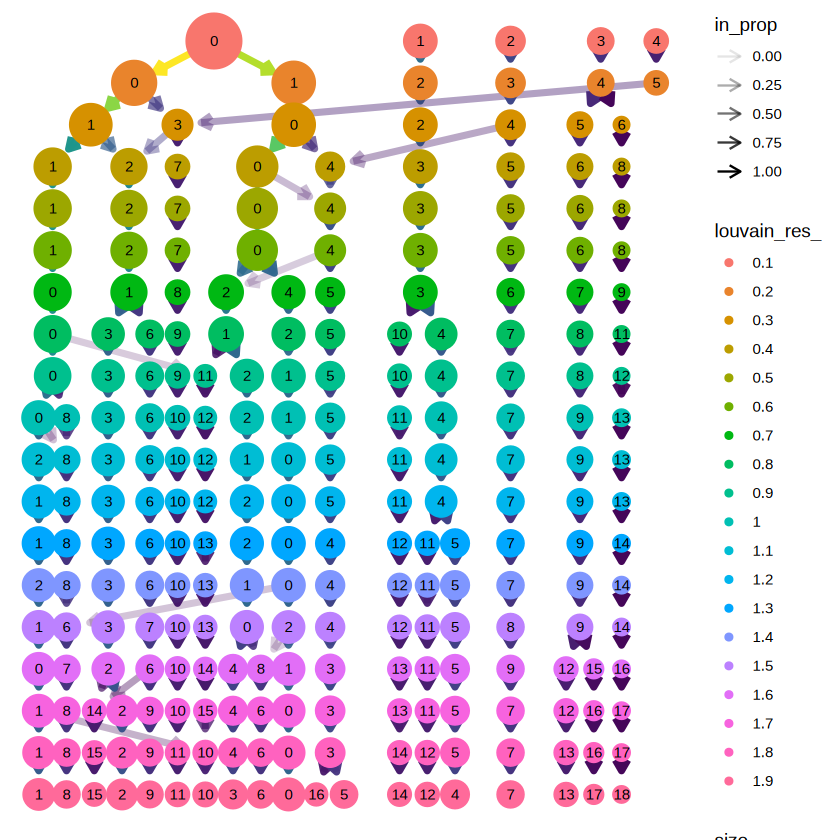

In [37]:
clustree_plot_louvain <- clustree(seurat_integrated@meta.data, prefix = "louvain_res_")
clustree_plot_louvain

ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_withIntegration_louvain_clustree.png"),
  plot = clustree_plot_louvain,
  width = 12,
  height = 8,
  dpi = 300
)

### Leiden clustree

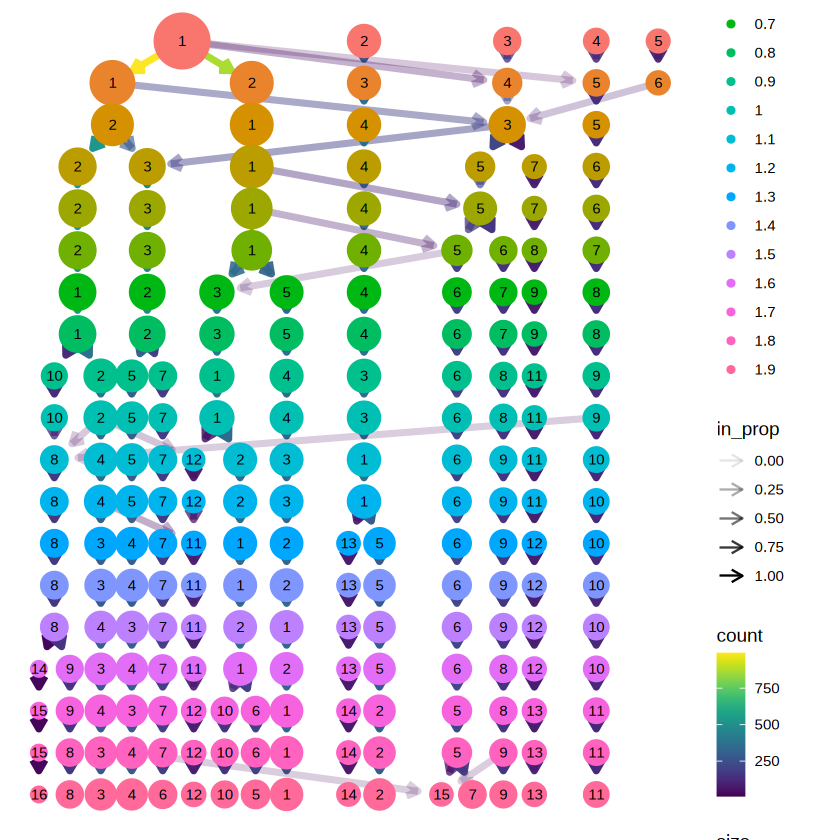

In [38]:
clustree_plot_leiden <- clustree(seurat_integrated@meta.data, prefix = "leiden_res_")
clustree_plot_leiden

ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_withIntegration_leiden_clustree.png"),
  plot = clustree_plot_leiden,
  width = 12,
  height = 8,
  dpi = 300
)

### Select resolution Louvain

In [39]:
cluster_key_louvain <- "louvain_res_0.4"

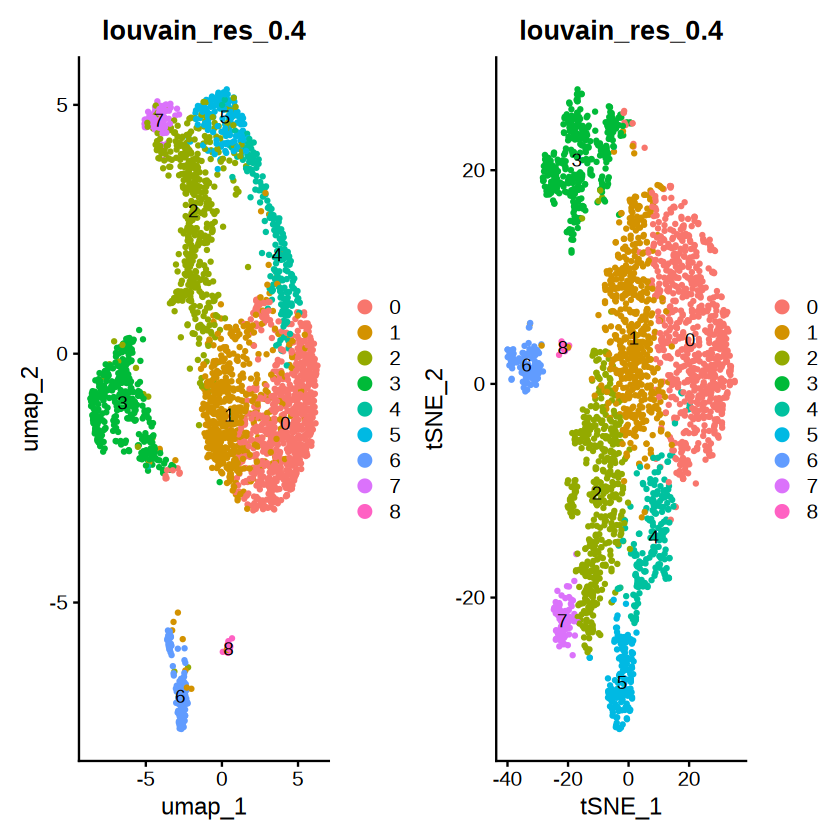

In [40]:
p_final_umap <- DimPlot(seurat_integrated, 
                        reduction = "umap", 
                        group.by = cluster_key_louvain, 
                        label = TRUE) +ggtitle(paste0(cluster_key_louvain))
p_final_tsne <- DimPlot(seurat_integrated, 
                        reduction = "tsne", 
                        group.by = cluster_key_louvain, 
                        label = TRUE) + ggtitle(paste0(cluster_key_louvain))
p_final <- p_final_umap | p_final_tsne
p_final

ggsave(
  filename = file.path(FIGURE_DIR,paste0("mIEC_seurat_withIntegration_",cluster_key_louvain,"_umap_tsne.png")),
  plot = p_final,
  width = 20,
  height = 10,
  dpi = 300
)

### Select resolution Leiden

In [41]:
cluster_key_leiden <- "leiden_res_0.4"

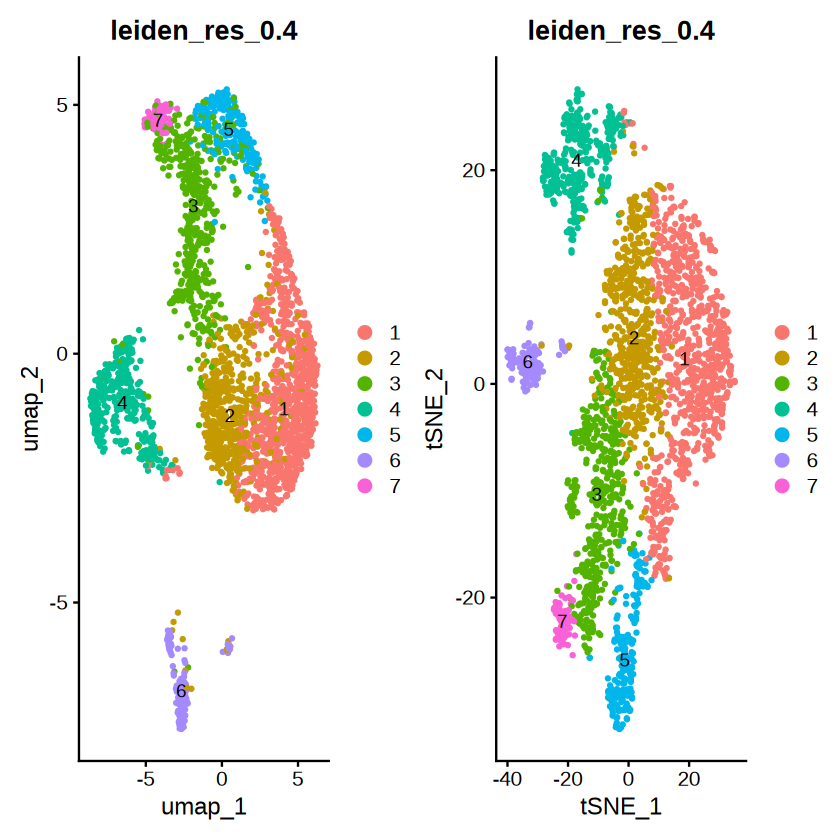

In [42]:
p_final_umap <- DimPlot(seurat_integrated, 
                        reduction = "umap", 
                        group.by = cluster_key_leiden, 
                        label = TRUE) +ggtitle(paste0(cluster_key_leiden))
p_final_tsne <- DimPlot(seurat_integrated, 
                        reduction = "tsne", 
                        group.by = cluster_key_leiden, 
                        label = TRUE) + ggtitle(paste0(cluster_key_leiden))
p_final <- p_final_umap | p_final_tsne
p_final

ggsave(
  filename = file.path(FIGURE_DIR, paste0("mIEC_seurat_withIntegration_",cluster_key_leiden,"_umap_tsne.png")),
  plot = p_final,
  width = 20,
  height = 10,
  dpi = 300
)

## final selected resolution (Louvain 0.4)

In [43]:
cluster_key <- "louvain_res_0.4"

seurat_integrated$final_clusters <- seurat_integrated@meta.data[[cluster_key]]
Idents(seurat_integrated) <- "final_clusters"

table(seurat_integrated$final_clusters)


  0   1   2   3   4   5   6   7   8 
732 520 467 359 198 152 118  91  19 

## UMAP by condition

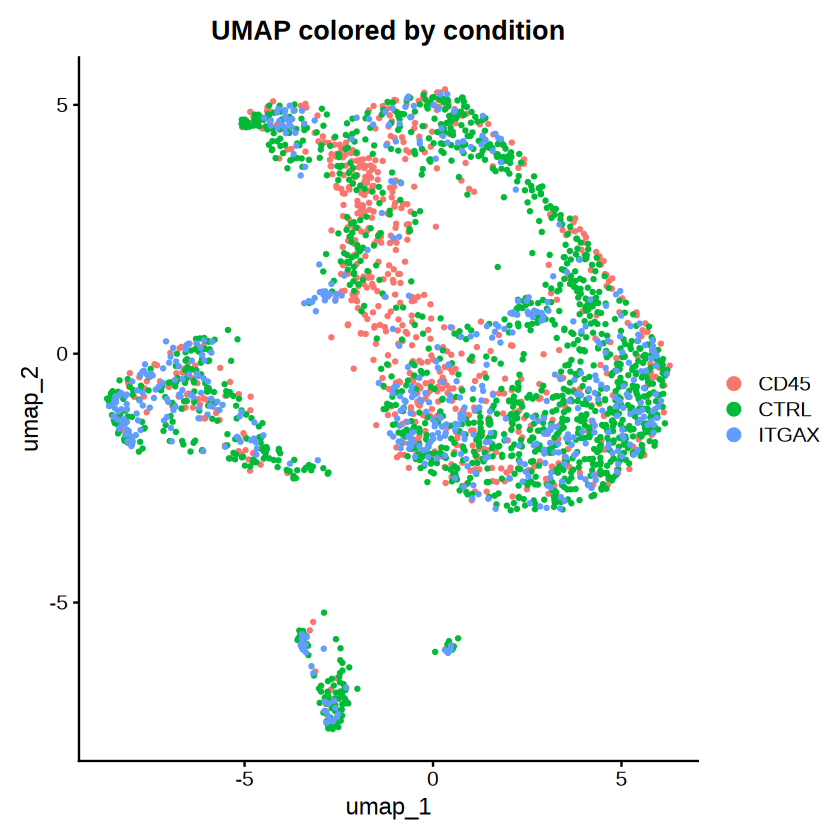

In [44]:
p_umap_condition_only <- DimPlot(
  seurat_integrated,
  reduction = "umap",
  group.by = "condition"
) +
  ggtitle("UMAP colored by condition")

p_umap_condition_only

ggsave(
  filename = file.path(
    FIGURE_DIR,
    "mIEC_seurat_withIntegration_umap_by_condition.png"
  ),
  plot = p_umap_condition_only,
  width = 8,
  height = 6,
  dpi = 300
)

## UMAP by sample  


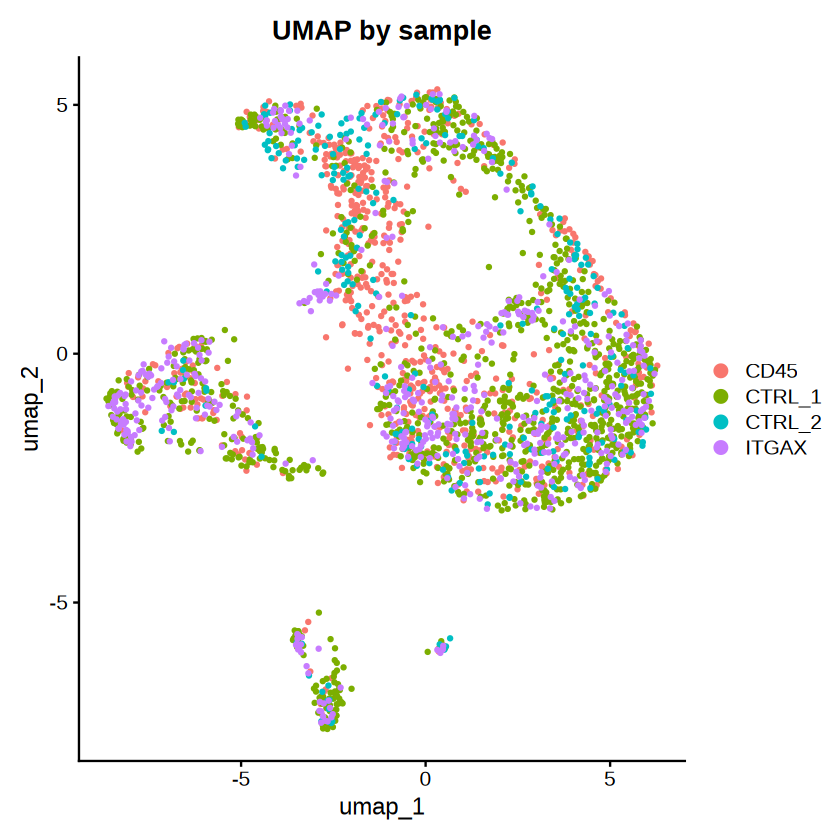

In [45]:
p_umap_by_sample_all <- DimPlot(
  seurat_integrated,
  reduction = "umap",
  group.by = "sample"
) +
  ggtitle("UMAP by sample")


p_umap_by_sample_all 

ggsave(
  filename = file.path(
    FIGURE_DIR,
    "mIEC_seurat_withIntegration_umap_by_sample_all.png"
  ),
  plot = p_umap_by_sample_all,
  width = 8,
  height = 6,
  dpi = 300
)


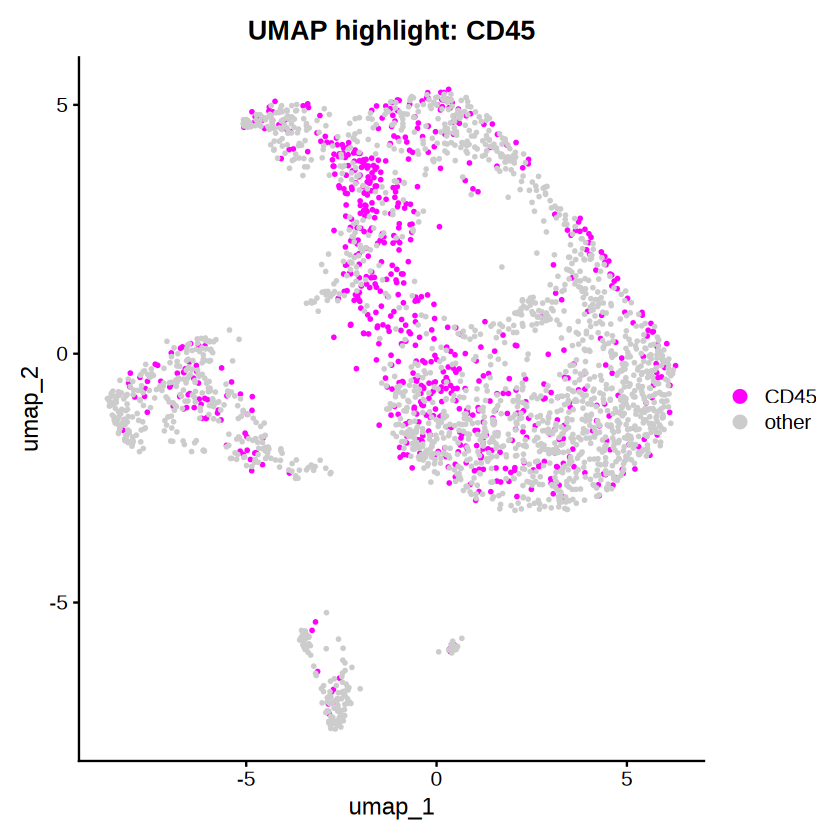

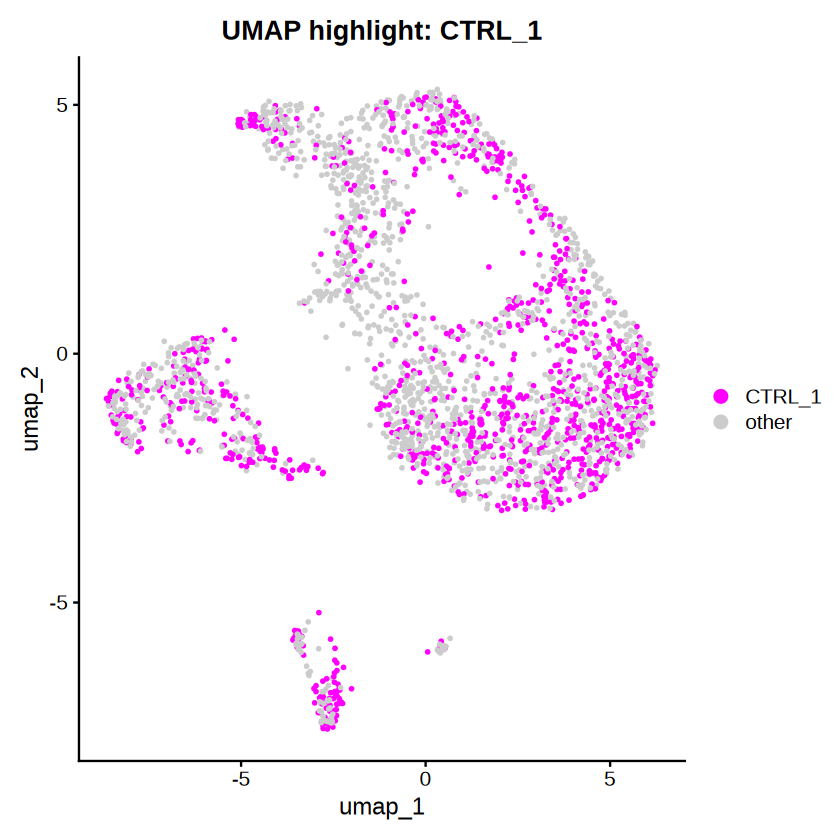

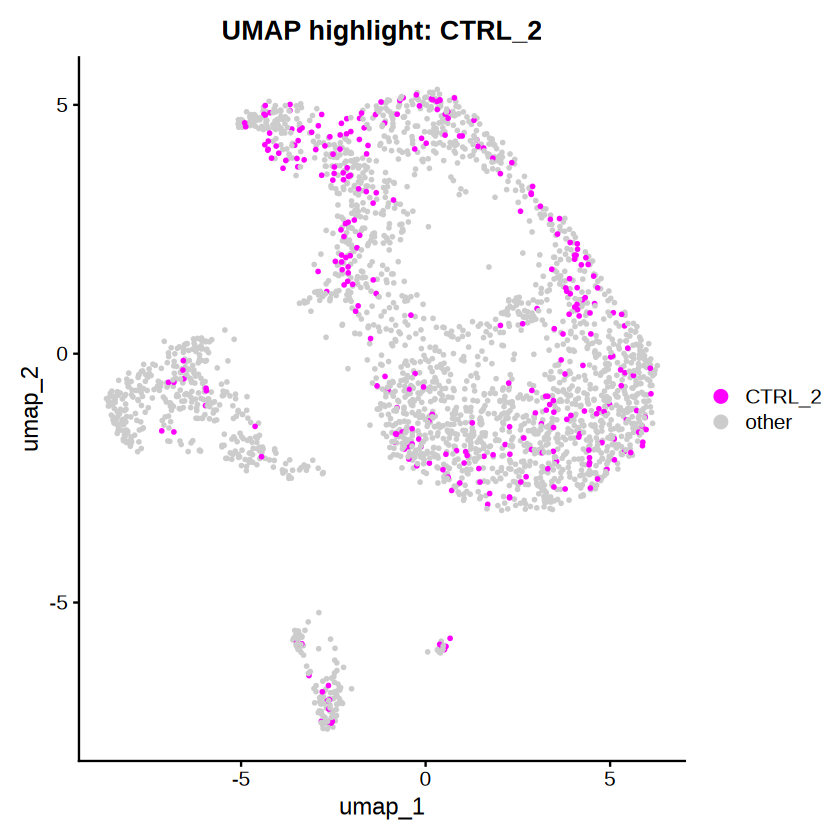

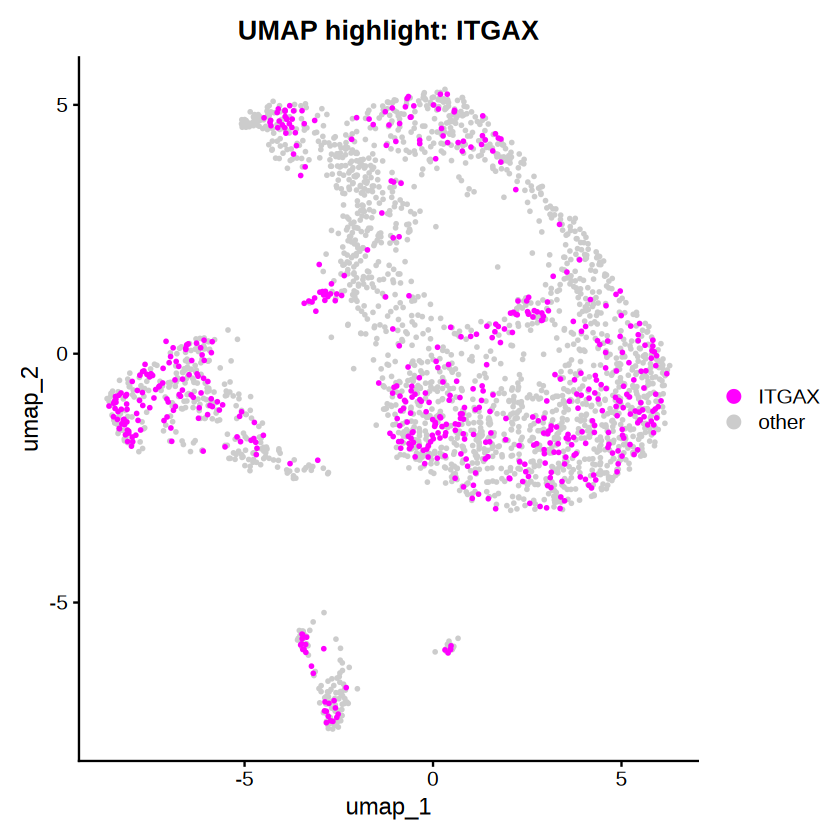

In [46]:
# Highlight each sample separately on the same UMAP

samples <- unique(seurat_integrated$sample)

for (sample_name in samples) {
  
  highlight_column <- paste0("highlight_", sample_name)
  
  seurat_integrated@meta.data[[highlight_column]] <- ifelse(
    seurat_integrated$sample == sample_name,
    sample_name,
    "other"
  )
  
  p_highlight_sample <- DimPlot(
    seurat_integrated,
    reduction = "umap",
    group.by = highlight_column,
    cols = c("magenta", "grey80"),
    pt.size = 0.4
  ) +
    ggtitle(paste0("UMAP highlight: ", sample_name))
  
  print(p_highlight_sample)
  
  ggsave(
    filename = file.path(
      FIGURE_DIR,
      paste0("mIEC_seurat_withIntegration_umap_highlight_", sample_name, ".png")
    ),
    plot = p_highlight_sample,
    width = 8,
    height = 6,
    dpi = 300
  )
}

## UMAP by final clusters 

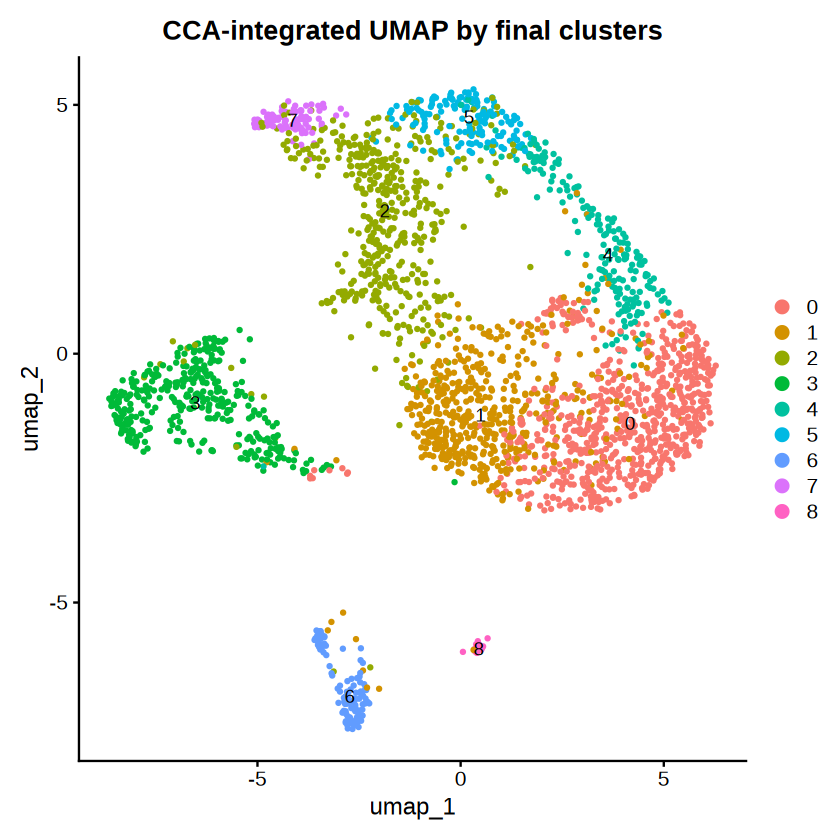

In [47]:
p_umap_clusters_integrated <- DimPlot(
  seurat_integrated,
  reduction = "umap",
  group.by = "final_clusters",
  label = TRUE
) +
  ggtitle("CCA-integrated UMAP by final clusters")

p_umap_clusters_integrated

ggsave(
  filename = file.path(
    FIGURE_DIR,
    "mIEC_seurat_withIntegration_umap_by_final_clusters.png"
  ),
  plot = p_umap_by_sample_all,
  width = 8,
  height = 6,
  dpi = 300
)

## combined in order to evaluate integration 

In [48]:
# Scanpy-like / thesis-style UMAP theme for Seurat
theme_umap_python_style <- theme_classic(base_size = 12) +
  theme(
    aspect.ratio = 1,
    plot.title = element_text(hjust = 0.5, size = 14),
    axis.title = element_text(size = 13),
    axis.text = element_text(size = 11),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 0.8),
    panel.grid.major = element_line(color = "grey85", linewidth = 0.4),
    panel.grid.minor = element_blank(),
    legend.title = element_blank(),
    legend.text = element_text(size = 11)
  )

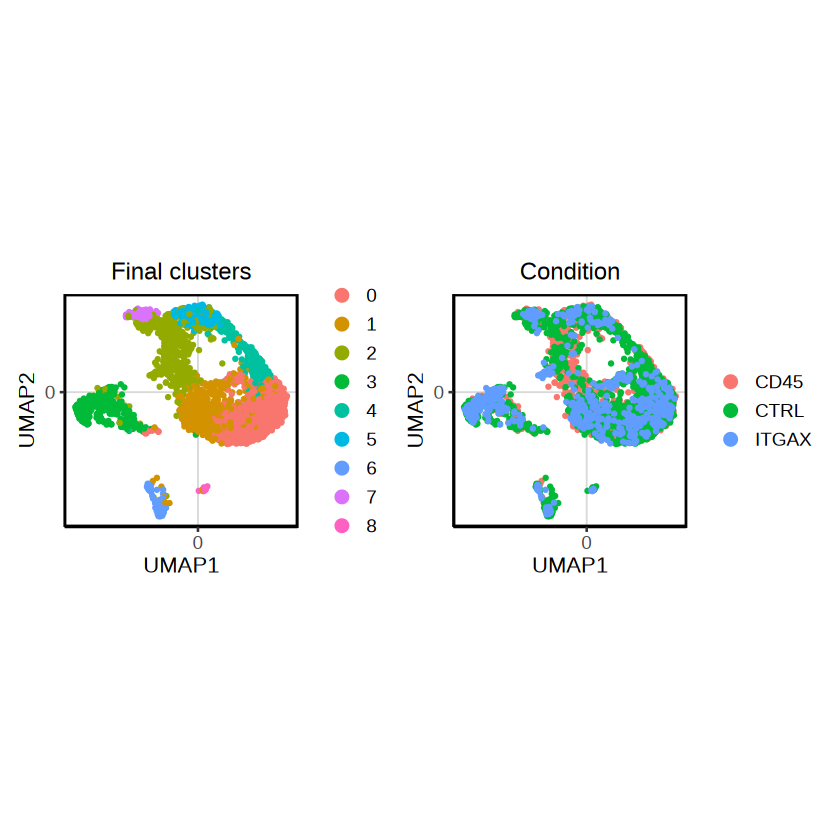

In [49]:
p_cca_clusters <- DimPlot(
  seurat_integrated,
  reduction = "umap",
  group.by = "final_clusters",
  label = FALSE,
  pt.size = 0.6
) +
  labs(title = "Final clusters", x = "UMAP1", y = "UMAP2") +
  scale_x_continuous(breaks = c(-10, 0, 10)) +
  scale_y_continuous(breaks = c(-10, 0, 10)) +
  coord_fixed() +
  theme_umap_python_style

p_cca_condition <- DimPlot(
  seurat_integrated,
  reduction = "umap",
  group.by = "condition",
  pt.size = 0.6
) +
  labs(title = "Condition", x = "UMAP1", y = "UMAP2") +
  scale_x_continuous(breaks = c(-10, 0, 10)) +
  scale_y_continuous(breaks = c(-10, 0, 10)) +
  coord_fixed() +
  theme_umap_python_style

p_cca_combined <- p_cca_clusters | p_cca_condition

p_cca_combined

ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_CCAintegration_combined_umap_python_style.png"),
  plot = p_cca_combined,
  width = 14,
  height = 6,
  dpi = 300
)


# 15. Marker genes using all cells and Louvain clusterin resolution 0.4

## set default assay as RNA

In [50]:
DefaultAssay(seurat_integrated) <- "RNA"

# Join RNA layers for Seurat v5
seurat_integrated <- JoinLayers(
  object = seurat_integrated,
  assay = "RNA"
)


## Normalize

In [51]:
seurat_integrated <- NormalizeData(
  seurat_integrated,
  assay = "RNA",
  normalization.method = "LogNormalize",
  scale.factor = 10000,
  verbose = FALSE
)

## scale all genes for better heatmaps

In [52]:
seurat_integrated <- ScaleData(
  seurat_integrated,
  features = rownames(seurat_integrated)
)

Centering and scaling data matrix



## find all marker genes

In [53]:
markers <- FindAllMarkers(
  seurat_integrated,
  assay = "RNA",
  only.pos = TRUE,
  test.use = "wilcox",
  logfc.threshold = 0.25,
  min.pct = 0.1
)

# Check marker table
cat("all markers before filter:", nrow(markers), "\n")
head(markers)

Calculating cluster 0

For a (much!) faster implementation of the Wilcoxon Rank Sum Test,
(default method for FindMarkers) please install the presto package
--------------------------------------------
install.packages('devtools')
devtools::install_github('immunogenomics/presto')
--------------------------------------------
After installation of presto, Seurat will automatically use the more 
efficient implementation (no further action necessary).
This message will be shown once per session

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8



all markers before filter: 8489 


,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
Ptma,4.662375e-242,2.684253,0.908,0.305,8.142372e-238,0,Ptma
Rps18,1.052239e-189,2.296699,0.844,0.311,1.837630e-185,0,Rps18
Ncl,1.634624e-186,2.335489,0.889,0.432,2.854708e-182,0,Ncl
Npm1,1.290089e-185,2.957970,0.738,0.197,2.253012e-181,0,Npm1
Rps19,1.168478e-181,2.073608,0.891,0.411,2.040631e-177,0,Rps19
Rpl35,8.537730e-181,2.402910,0.806,0.263,1.491029e-176,0,Rpl35


## filter marker genes 

In [54]:
markers_filtered <- markers %>%
  filter(p_val_adj < 0.01, avg_log2FC > 0.25)

write.csv(markers, file.path(TABLE_DIR, "09_all_cluster_markers.csv"), row.names = FALSE)
write.csv(markers_filtered, file.path(TABLE_DIR, "10_filtered_cluster_markers.csv"), row.names = FALSE)

cat("all markers after filter:", nrow(markers_filtered), "\n")
head(markers_filtered)

all markers after filter: 5394 


,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
Ptma,4.662375e-242,2.684253,0.908,0.305,8.142372e-238,0,Ptma
Rps18,1.052239e-189,2.296699,0.844,0.311,1.837630e-185,0,Rps18
Ncl,1.634624e-186,2.335489,0.889,0.432,2.854708e-182,0,Ncl
Npm1,1.290089e-185,2.957970,0.738,0.197,2.253012e-181,0,Npm1
Rps19,1.168478e-181,2.073608,0.891,0.411,2.040631e-177,0,Rps19
Rpl35,8.537730e-181,2.402910,0.806,0.263,1.491029e-176,0,Rpl35


## select top 15 marke genes

In [55]:
TOP_N <- 15

top15_markers <- markers_filtered %>%
  group_by(cluster) %>%
  arrange(desc(avg_log2FC), .by_group = TRUE) %>%
  slice_head(n = TOP_N) %>%
  ungroup()

top15_genes <- unique(top15_markers$gene)

write.csv(top15_markers, file.path(TABLE_DIR, "11_seurat_withIntegration_top15_markers_per_cluster.csv"), row.names = FALSE)


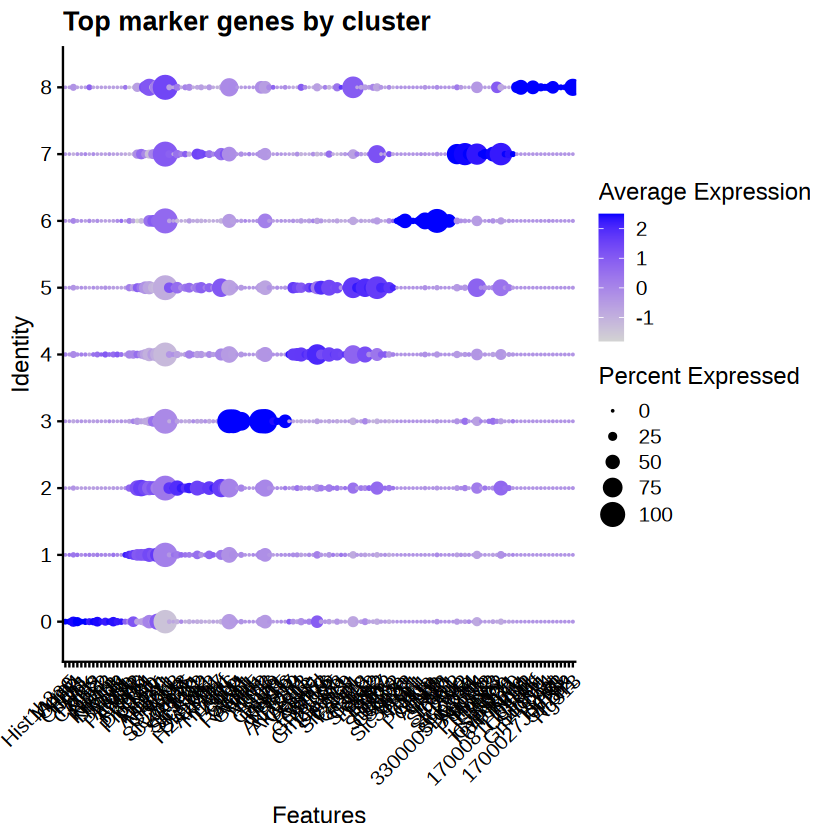

In [56]:
dotplot_markers <- DotPlot(seurat_integrated, features = top15_genes, group.by = "final_clusters") +
  RotatedAxis() +
  ggtitle("Top marker genes by cluster")

dotplot_markers

ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_withIntegration_top15_markers_dotplot.png"),
  plot = dotplot_markers,
  width = 25,
  height = 10,
  dpi = 300
)

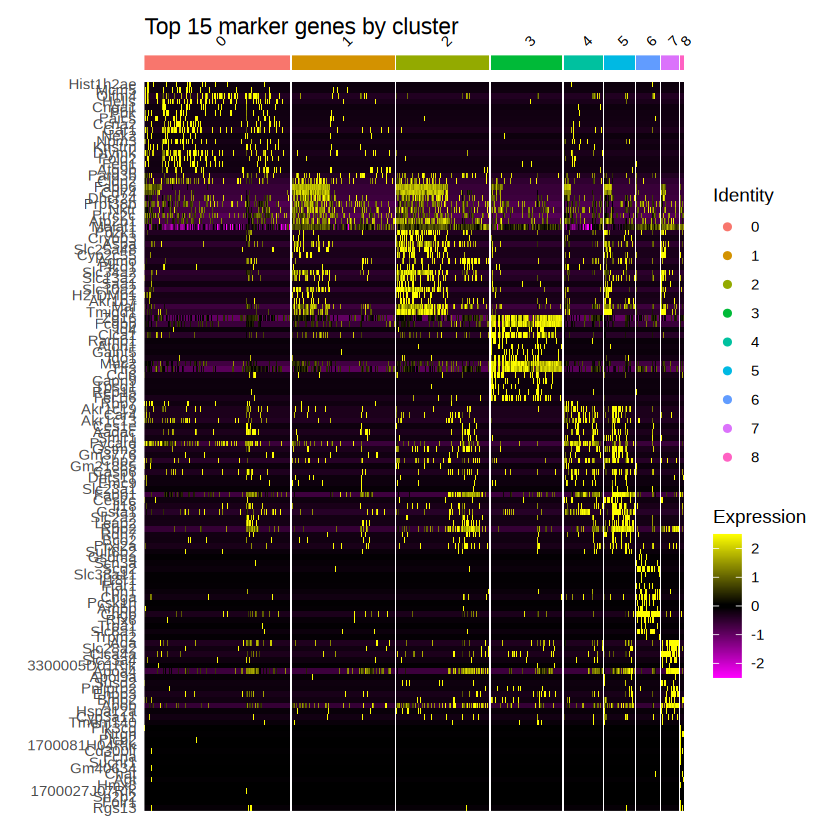

In [57]:
heatmap_markers <- DoHeatmap(
  seurat_integrated,
  features = top15_genes,
  group.by = "final_clusters",
  size = 3
) + ggtitle("Top 15 marker genes by cluster")

heatmap_markers

ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_withIntegration_top15_markers_heatmap.png"),
  plot = heatmap_markers,
  width = 20,
  height = 14,
  dpi = 300
)


# 16. Feature plots for top markers  


In [58]:
for (cl in sort(unique(as.character(top15_markers$cluster)))) {
  genes_cl <- top15_markers %>%
    filter(as.character(cluster) == cl) %>%
    pull(gene) %>%
    unique()
  
  genes_cl <- genes_cl[genes_cl %in% rownames(seurat_integrated)]
  
  cat("Cluster:", cl, "\n")
  print(genes_cl)
  
  if (length(genes_cl) > 0) {
    p <- FeaturePlot(
      seurat_integrated,
      features = genes_cl,
      reduction = "umap",
      ncol = 4
    )
    
    ggsave(
      filename = file.path(FIGURE_DIR, paste0("mIEC_seurat_withIntegration_cluster_", cl, "_top_marker_featureplots.png")),
      plot = p,
      width = 14,
      height = 10,
      dpi = 300
    )
  }
}

Cluster: 0 
 [1] "Hist1h2ae" "Mcm5"      "Olfm4"     "Hells"     "Cnga1"     "Pbk"      
 [7] "Paics"     "Ccna2"     "Gar1"      "Nek2"      "Npm3"      "Knstrn"   
[13] "Dtymk"     "Pold2"     "Fen1"     
Cluster: 1 
 [1] "Atg9b"   "Pard3b"  "Cldn2"   "Fabp6"   "Cd74"    "Dhcr24"  "Prpf38b"
 [8] "Nktr"    "Prrc2c"  "Atp2b1"  "Malat1" 
Cluster: 2 
 [1] "Pdzk1"    "Crybb3"   "Aspa"     "Slc25a48" "Cyp2c55"  "Agmo"    
 [7] "Plcd1"    "Slc34a2"  "Slc13a2"  "Saa1"     "Slc10a2"  "H2-DMb1" 
[13] "Akr1b7"   "Maf"      "Tmigd1"  
Cluster: 3 
 [1] "Zg16"   "Fcgbp"  "Id4"    "Clca1"  "Ramp1"  "Atoh1"  "Galnt5" "Ido1"  
 [9] "Muc2"   "Tff3"   "Ccl6"   "Capn9"  "Tpsg1"  "Rep15"  "Fer1l6"
Cluster: 4 
 [1] "Rbp7"    "Akr1c19" "Car4"    "Akr1c13" "Ces1e"   "Aadac"   "Smlr1"  
 [8] "Pycard"  "Gstm3"   "Gm3776"  "Chp2"    "Gm21885" "Casp6"   "Dhrs11" 
[15] "Emc9"   
Cluster: 5 
 [1] "Slc23a1" "Fabp1"   "Ces2c"   "Il18"    "Gsta1"   "Slc2a2"  "Leap2"  
 [8] "Rbp2"    "Gm3776"  "Gstm3"   "Smlr1"   "Rd



# 17. Markers by condition  



In [59]:
condition_marker_tables <- list()

MIN_CELLS_PER_CLUSTER <- 10

for (cond in unique(seurat_integrated$condition)) {
  cat("Running marker detection for condition:", cond, "\n")
  
  obj_cond <- subset(seurat_integrated, subset = condition == cond)
  
  cluster_counts <- table(obj_cond$final_clusters)
  valid_clusters <- names(cluster_counts[cluster_counts >= MIN_CELLS_PER_CLUSTER])
  obj_cond <- subset(obj_cond, subset = final_clusters %in% valid_clusters)
  
  if (length(unique(obj_cond$final_clusters)) < 2) {
    cat("Skipped", cond, "- fewer than 2 valid clusters\n")
    next
  }
  
  Idents(obj_cond) <- "final_clusters"
  
  markers_cond <- FindAllMarkers(
    obj_cond,
    assay = "RNA",
    only.pos = TRUE,
    test.use = "wilcox",
    logfc.threshold = 0.25,
    min.pct = 0.1
  )
  
  markers_cond$condition <- cond
  condition_marker_tables[[cond]] <- markers_cond
}

markers_by_condition <- bind_rows(condition_marker_tables)

markers_by_condition_filtered <- markers_by_condition %>%
  filter(p_val_adj < 0.05, avg_log2FC > 0.25)

write.csv(markers_by_condition, file.path(TABLE_DIR, "12_seurat_withIntegration_markers_by_condition.csv"), row.names = FALSE)
write.csv(markers_by_condition_filtered, file.path(TABLE_DIR, "13_seurat_withIntegration_filtered_markers_by_condition.csv"), row.names = FALSE)

cat("Markers by condition:", nrow(markers_by_condition_filtered), "\n")
head(markers_by_condition_filtered)

Running marker detection for condition: CD45 


Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 7



Running marker detection for condition: CTRL 


Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8



Running marker detection for condition: ITGAX 


Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7



Markers by condition: 9312 


,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene,condition
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>,<chr>
Clca3b...1,3.729259e-58,5.177558,0.674,0.059,6.512778e-54,0,Clca3b,CD45
Ptma...2,4.681485e-54,4.103869,0.872,0.188,8.175745e-50,0,Ptma,CD45
Mki67...3,1.568329e-48,6.012985,0.465,0.021,2.738929e-44,0,Mki67,CD45
Hspd1...4,2.376124e-48,4.191206,0.686,0.093,4.149663e-44,0,Hspd1,CD45
Snrpg...5,1.457325e-47,4.339297,0.581,0.054,2.545072e-43,0,Snrpg,CD45
Ccnd1...6,4.089373e-46,4.199496,0.547,0.044,7.141681e-42,0,Ccnd1,CD45



# 18. Heatmaps per condition  
 


In [60]:
for (cond in unique(seurat_integrated$condition)) {
  cat("Plotting heatmap for condition:", cond, "\n")
  
  obj_cond <- subset(seurat_integrated, subset = condition == cond)
  
  heatmap_cond <- DoHeatmap(
    obj_cond,
    features = top15_genes,
    group.by = "final_clusters",
    size = 3
  ) + ggtitle(paste("Top marker genes -", cond))
  
  ggsave(
    filename = file.path(FIGURE_DIR, paste0("mIEC_seurat_withIntegration_top15_marker_heatmap_condition_", cond, ".png")),
    plot = heatmap_cond,
    width = 14,
    height = 10,
    dpi = 300
  )
}

Plotting heatmap for condition: CD45 
Plotting heatmap for condition: CTRL 
Plotting heatmap for condition: ITGAX 



# 19. Conserved markers across conditions  


In [61]:
conserved_markers <- markers_by_condition_filtered %>%
  group_by(cluster, gene) %>%
  summarise(
    n_experiments = n_distinct(condition),
    experiments = paste(sort(unique(condition)), collapse = ", "),
    mean_logfoldchange = mean(avg_log2FC, na.rm = TRUE),
    min_logfoldchange = min(avg_log2FC, na.rm = TRUE),
    mean_pvals_adj = mean(p_val_adj, na.rm = TRUE),
    max_pvals_adj = max(p_val_adj, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  filter(
    n_experiments >= 2,
    max_pvals_adj < 0.05,
    min_logfoldchange > 0.25
  ) %>%
  arrange(cluster, desc(n_experiments), desc(mean_logfoldchange))

write.csv(conserved_markers, file.path(TABLE_DIR, "14_conserved_markers.csv"), row.names = FALSE)

cat("Conserved markers:", nrow(conserved_markers), "\n")
head(conserved_markers)

Conserved markers: 2129 


cluster,gene,n_experiments,experiments,mean_logfoldchange,min_logfoldchange,mean_pvals_adj,max_pvals_adj
<fct>,<chr>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
0,Pclaf,3,"CD45, CTRL, ITGAX",5.045521,2.380033,1.798900e-11,5.396699e-11
0,Cenpa,3,"CD45, CTRL, ITGAX",4.702110,1.709204,4.260116e-07,1.278035e-06
0,Slfn9,3,"CD45, CTRL, ITGAX",4.688427,2.060238,5.160821e-07,1.548246e-06
0,Mcm3,3,"CD45, CTRL, ITGAX",4.635530,1.870145,9.757513e-10,2.911696e-09
0,Tpx2,3,"CD45, CTRL, ITGAX",4.612745,1.210519,4.600456e-04,1.380137e-03
0,Stmn1,3,"CD45, CTRL, ITGAX",4.207717,2.466182,1.098812e-10,3.296435e-10


## Select top 15 conserved markers by fold change

In [62]:
TOP_N_CONSERVED <- 15

top15_conserved_by_fc <- conserved_markers %>%
  group_by(cluster) %>%
  arrange(desc(mean_logfoldchange), .by_group = TRUE) %>%
  slice_head(n = TOP_N_CONSERVED) %>%
  ungroup()

write.csv(top15_conserved_by_fc, file.path(TABLE_DIR, "16_seurat_withIntegration_top15_conserved_markers_by_foldchange.csv"), row.names = FALSE)

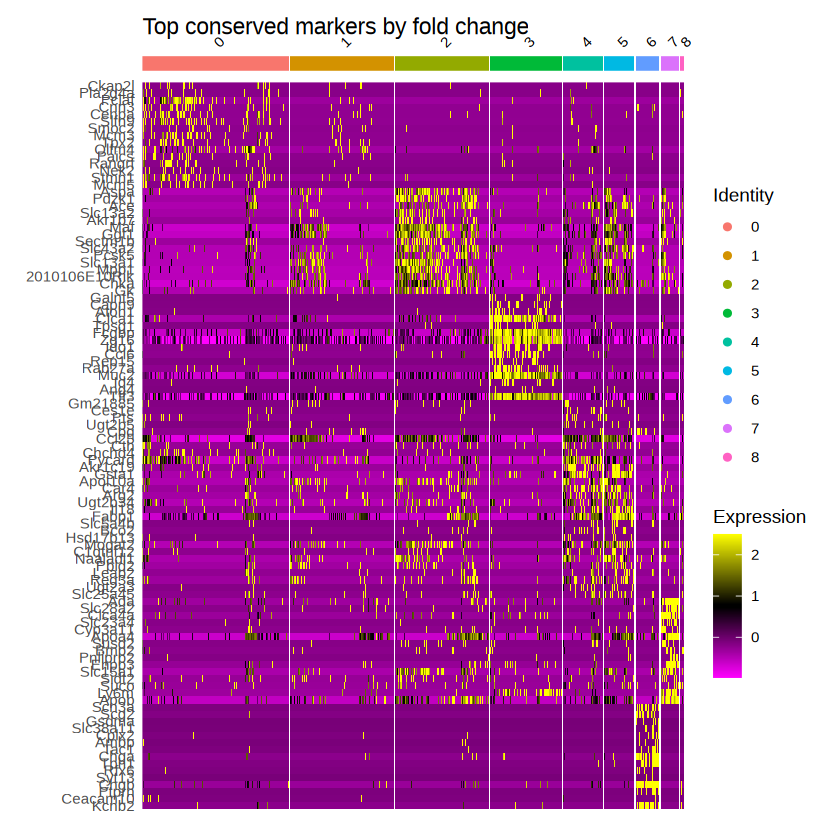

In [63]:
top15_conserved_fc_genes <- unique(top15_conserved_by_fc$gene)

conserved_heatmap <- DoHeatmap(
  seurat_integrated,
  features = top15_conserved_fc_genes,
  group.by = "final_clusters",
  size = 3
) + ggtitle("Top conserved markers by fold change")

conserved_heatmap

ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_withIntegration_top15_conserved_markers_by_fc_heatmap.png"),
  plot = conserved_heatmap,
  width = 14,
  height = 10,
  dpi = 300
)

## Select top 15 conserved markers by p value

In [64]:
top15_conserved_by_pvalue <- conserved_markers %>%
  group_by(cluster) %>%
  arrange(max_pvals_adj, .by_group = TRUE) %>%
  slice_head(n = TOP_N_CONSERVED) %>%
  ungroup()

write.csv(top15_conserved_by_pvalue, file.path(TABLE_DIR, "15_seurat_withIntegration_top15_conserved_markers_by_pvalue.csv"), row.names = FALSE)


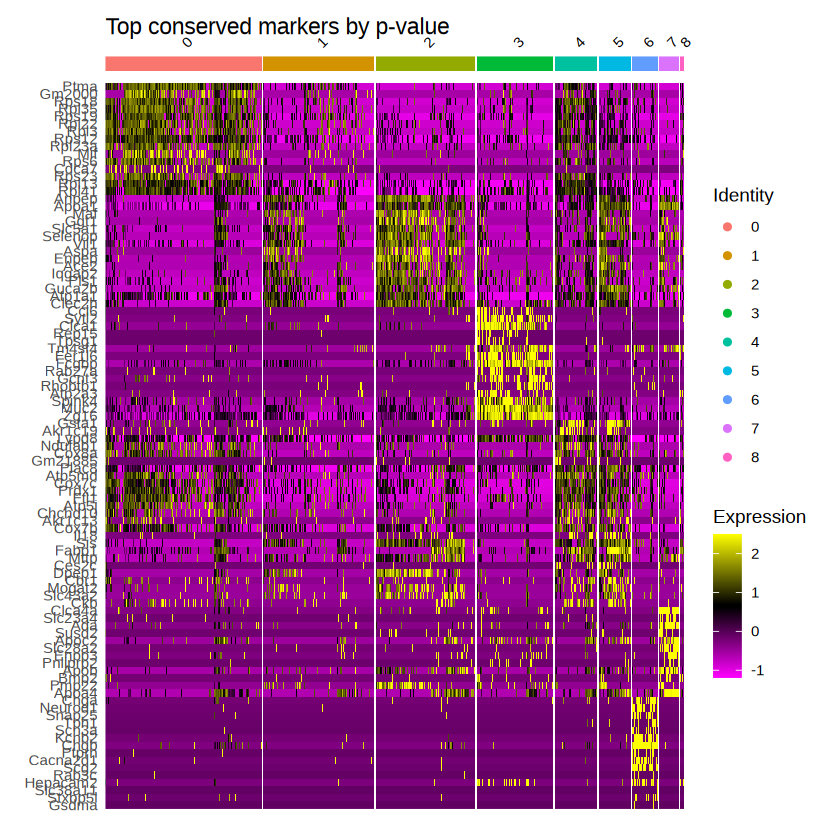

In [65]:
top15_conserved_pvalue_genes <- unique(top15_conserved_by_pvalue$gene)

conserved_heatmap <- DoHeatmap(
  seurat_integrated,
  features = top15_conserved_pvalue_genes,
  group.by = "final_clusters",
  size = 3
) + ggtitle("Top conserved markers by p-value ")

conserved_heatmap

ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_withIntegration_top15_conserved_markers_by_pvalue_heatmap.png"),
  plot = conserved_heatmap,
  width = 14,
  height = 10,
  dpi = 300
)



# 20. Conserved markers without ribosomal/mitochondrial genes  



In [66]:
conserved_markers_no_ribo <- conserved_markers %>%
  filter(!str_detect(str_to_upper(gene), "^(RPS|RPL|MT-)"))

write.csv(
  conserved_markers_no_ribo,
  file.path(TABLE_DIR, "17_seurat_withIntegration_conserved_markers_no_ribo_mt.csv"),
  row.names = FALSE
)

cat("Conserved markers without ribosomal/mitacondrial genes:", nrow(conserved_markers_no_ribo), "\n")
head(conserved_markers_no_ribo)

Conserved markers without ribosomal/mitacondrial genes: 2015 


cluster,gene,n_experiments,experiments,mean_logfoldchange,min_logfoldchange,mean_pvals_adj,max_pvals_adj
<fct>,<chr>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
0,Pclaf,3,"CD45, CTRL, ITGAX",5.045521,2.380033,1.798900e-11,5.396699e-11
0,Cenpa,3,"CD45, CTRL, ITGAX",4.702110,1.709204,4.260116e-07,1.278035e-06
0,Slfn9,3,"CD45, CTRL, ITGAX",4.688427,2.060238,5.160821e-07,1.548246e-06
0,Mcm3,3,"CD45, CTRL, ITGAX",4.635530,1.870145,9.757513e-10,2.911696e-09
0,Tpx2,3,"CD45, CTRL, ITGAX",4.612745,1.210519,4.600456e-04,1.380137e-03
0,Stmn1,3,"CD45, CTRL, ITGAX",4.207717,2.466182,1.098812e-10,3.296435e-10



# 21. Stress signature  


In [67]:
stress_genes_input <- c("Bcl2", "Tnf", "Trp53", "Casp3", "Bax", "Casp8", "Fas")
stress_genes <- stress_genes_input[stress_genes_input %in% rownames(seurat_integrated)]
missing_stress_genes <- setdiff(stress_genes_input, stress_genes)

cat("Stress genes found:", paste(stress_genes, collapse = ", "), "\n")
cat("Stress genes missing:", paste(missing_stress_genes, collapse = ", "), "\n")

if (length(stress_genes) == 0) {
  stop("No stress genes were found. Check gene naming.")
}

seurat_integrated <- AddModuleScore(
  seurat_integrated,
  features = list(stress_genes),
  name = "stress_signature"
)

# Seurat appends 1 to the module score name
seurat_integrated$stress_signature <- seurat_integrated$stress_signature1
head(seurat_integrated@meta.data[, c("stress_signature")])

Stress genes found: Bcl2, Tnf, Trp53, Casp3, Bax, Casp8, Fas 
Stress genes missing:  


[1]  0.161574263 -0.002387462  0.102143204  0.016522024  0.072571499
[6] -0.073844029

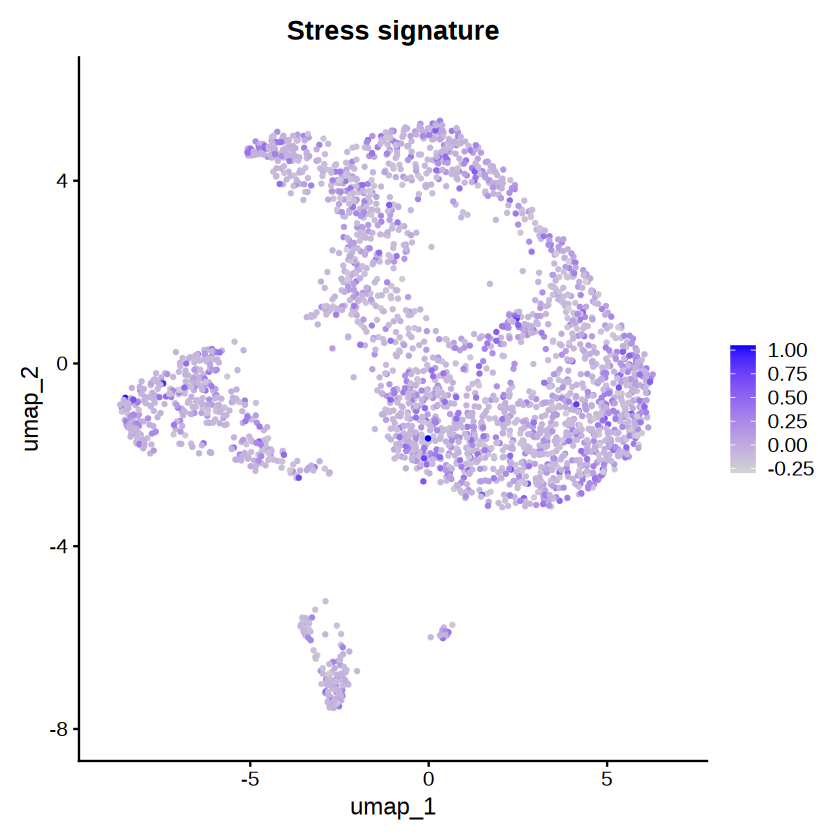

In [68]:
stress_umap <- FeaturePlot(
  seurat_integrated,
  features = "stress_signature",
  reduction = "umap"
) + ggtitle("Stress signature")

stress_umap

ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_withIntegration_stress_signature_umap.png"),
  plot = stress_umap,
  width = 7,
  height = 6,
  dpi = 300
)


# 22. Stress signature by cluster

In [69]:
stress_by_cluster <- seurat_integrated@meta.data %>%
  group_by(final_clusters) %>%
  summarise(
    count = n(),
    mean = mean(stress_signature, na.rm = TRUE),
    median = median(stress_signature, na.rm = TRUE),
    min = min(stress_signature, na.rm = TRUE),
    max = max(stress_signature, na.rm = TRUE),
    .groups = "drop"
  )

write.csv(stress_by_cluster, file.path(TABLE_DIR, "18_stress_signature_by_cluster.csv"), row.names = FALSE)
stress_by_cluster

final_clusters,count,mean,median,min,max
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
0,732,0.032210823,-0.05055765,-0.2947859,0.8455743
1,520,0.008497770,-0.07587424,-0.2601920,1.0489038
2,467,-0.030114465,-0.08819588,-0.2954774,0.5907275
3,359,0.003712725,-0.06839917,-0.2425172,1.0244548
4,198,-0.001841327,-0.06678035,-0.2902239,0.5717188
5,152,0.048007592,-0.01708626,-0.1984044,0.5925021
6,118,-0.034912344,-0.08595925,-0.2375295,0.6174805
7,91,0.043822791,-0.04895908,-0.1773663,0.5488811
8,19,0.014558333,-0.05870170,-0.2095167,0.4359939


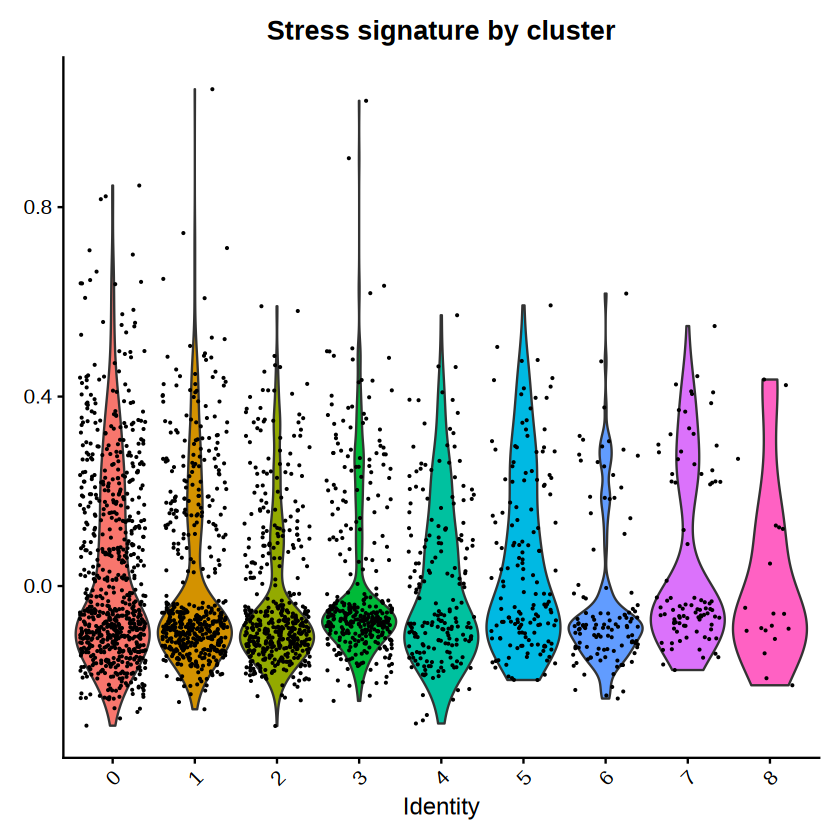

In [70]:

p_cluster_violin <- VlnPlot(
  seurat_integrated,
  features = "stress_signature",
  group.by = "final_clusters",
  pt.size = 0.1
) + NoLegend() + ggtitle("Stress signature by cluster")

p_cluster_violin

ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_withIntegration_stress_signature_by_cluster.png"),
  plot = p_cluster_violin,
  width = 12,
  height = 5,
  dpi = 300
)

# 23. Stress signature by condition

In [71]:
stress_by_condition <- seurat_integrated@meta.data %>%
  group_by(condition) %>%
  summarise(
    count = n(),
    mean = mean(stress_signature, na.rm = TRUE),
    median = median(stress_signature, na.rm = TRUE),
    min = min(stress_signature, na.rm = TRUE),
    max = max(stress_signature, na.rm = TRUE),
    .groups = "drop"
  )

write.csv(stress_by_condition, file.path(TABLE_DIR, "19_seurat_withIntegration_stress_signature_by_condition.csv"), row.names = FALSE)
stress_by_condition

condition,count,mean,median,min,max
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
CD45,708,0.0002442088,-0.07755014,-0.2449630,0.8455743
CTRL,1404,0.0044943824,-0.06932676,-0.2954774,1.0244548
ITGAX,544,0.0291561762,-0.06160423,-0.2204258,1.0489038


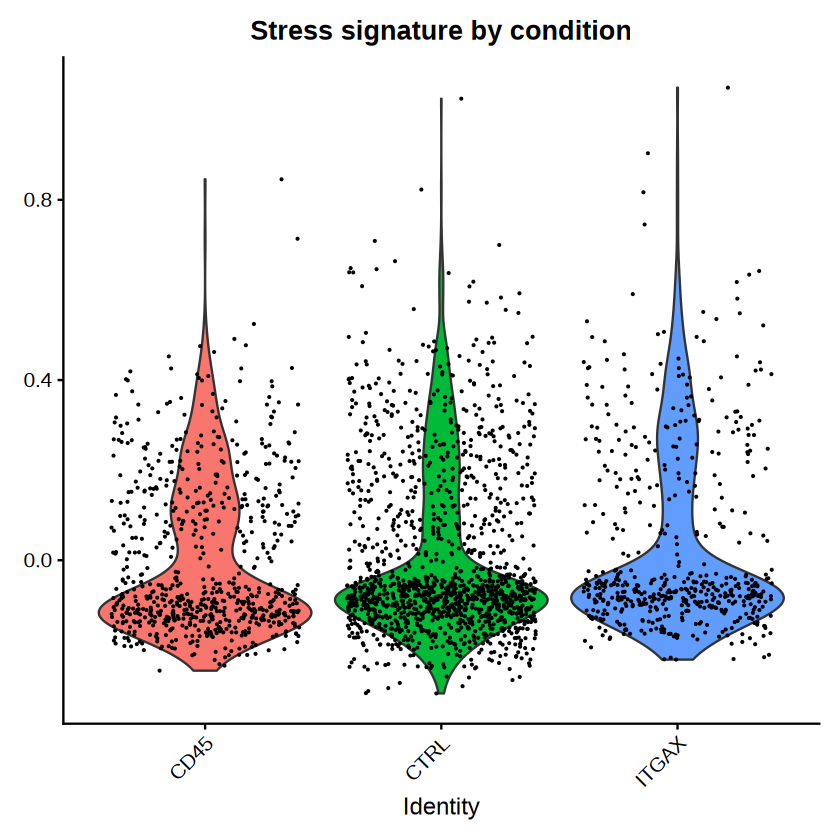

In [72]:
p_condition_violin <- VlnPlot(
  seurat_integrated,
  features = "stress_signature",
  group.by = "condition",
  pt.size = 0.1
) + NoLegend() + ggtitle("Stress signature by condition")

p_condition_violin

ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_withIntegration_stress_signature_by_condition.png"),
  plot = p_condition_violin,
  width = 10,
  height = 5,
  dpi = 300
)

# 24. Stress signature by cluster and condition

In [73]:
stress_by_cluster_condition <- seurat_integrated@meta.data %>%
  group_by(final_clusters, condition) %>%
  summarise(
    count = n(),
    mean = mean(stress_signature, na.rm = TRUE),
    median = median(stress_signature, na.rm = TRUE),
    min = min(stress_signature, na.rm = TRUE),
    max = max(stress_signature, na.rm = TRUE),
    .groups = "drop"
  )

write.csv(stress_by_cluster_condition, file.path(TABLE_DIR, "20_seurat_withIntegration_stress_signature_by_cluster_condition.csv"), row.names = FALSE)
stress_by_cluster_condition

final_clusters,condition,count,mean,median,min,max
<fct>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
0,CD45,86,0.025630581,-0.03616827,-0.23388566,0.8455743
0,CTRL,490,0.034224890,-0.04507189,-0.29478594,0.8227678
0,ITGAX,156,0.029512155,-0.05629348,-0.22042582,0.8167152
1,CD45,193,-0.001897166,-0.08627413,-0.24496304,0.7135995
1,CTRL,199,-0.012840133,-0.07869873,-0.26019202,0.6484221
1,ITGAX,128,0.057345155,-0.05634187,-0.18123692,1.0489038
2,CD45,259,-0.029590716,-0.09827790,-0.23057624,0.4622881
2,CTRL,160,-0.032519062,-0.07817556,-0.29547738,0.4857410
2,ITGAX,48,-0.024925202,-0.07510025,-0.17467856,0.5907275


In [74]:
stress_matrix <- stress_by_cluster_condition %>%
  select(final_clusters, condition, mean) %>%
  pivot_wider(names_from = condition, values_from = mean) %>%
  column_to_rownames("final_clusters") %>%
  as.matrix()

pheatmap(
  stress_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  main = "Mean stress signature by cluster and condition",
  filename = file.path(FIGURE_DIR, "mIEC_seurat_withIntegration_stress_signature_cluster_condition_heatmap.png"),
  width = 7,
  height = 5
)

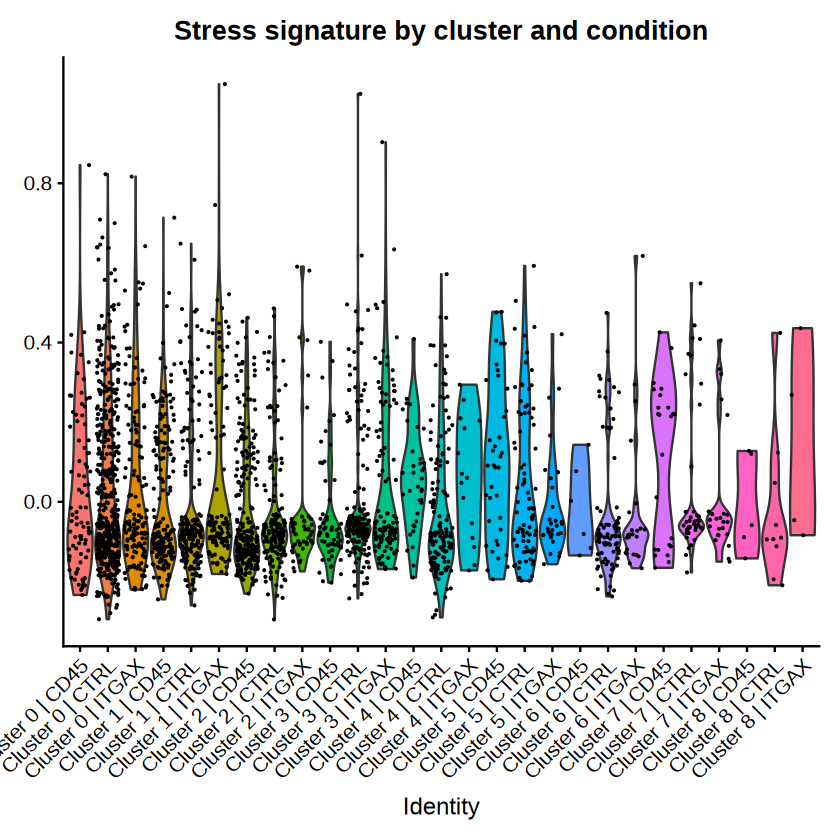

In [75]:
seurat_integrated$cluster_condition <- paste0(
  "Cluster ", seurat_integrated$final_clusters,
  " | ", seurat_integrated$condition
)

p_cluster_condition_violin <- VlnPlot(
  seurat_integrated,
  features = "stress_signature",
  group.by = "cluster_condition",
  pt.size = 0.1
) +
  NoLegend() +
  RotatedAxis() +
  ggtitle("Stress signature by cluster and condition")

p_cluster_condition_violin

ggsave(
  filename = file.path(FIGURE_DIR, "mIEC_seurat_withIntegration_stress_signature_cluster_condition_violin.png"),
  plot = p_cluster_condition_violin,
  width = 18,
  height = 7,
  dpi = 300
)

## check default assay

In [76]:
cat("Current default assay:", DefaultAssay(seurat_integrated), "\n")

Current default assay: RNA 



# 25. Save final object and session info

In [77]:
final_object <- file.path(
  OBJECT_DIR,
  "mIEC_seurat_withIntegration_processed_final_with_markers_stress.rds"
)

saveRDS(seurat_integrated, final_object)
cat("Saved final object:", final_object, "\n")

Saved final object: /CEPH/users/mtarzi/scRNA_sequencing_of_murine_intestinal_epithelial/seurat_CCA_Integration/objects/mIEC_seurat_withIntegration_processed_final_with_markers_stress.rds 


In [78]:
# run time
runtime <- Sys.time() - workflow_start

runtime_table <- data.frame(
  workflow = "Seurat_withIntegration",
  runtime_seconds = as.numeric(runtime, units = "secs"),
  runtime_minutes = as.numeric(runtime, units = "mins")
)

write.csv(runtime_table, file.path(TABLE_DIR, "21_seurat_withIntegration_runtime_summary.csv"), row.names = FALSE)

runtime_table

workflow,runtime_seconds,runtime_minutes
<chr>,<dbl>,<dbl>
Seurat_withIntegration,843.5953,14.05992


In [79]:
# Complete session information
sink(file.path(TABLE_DIR, "22_R_withIntegration_session_info.txt"))
cat("R session information\n")
cat("=====================\n")
print(sessionInfo())
sink()


In [80]:
# Package versions
important_packages <- c(
  "Seurat",
  "SeuratObject",
  "sctransform",
  "Matrix",
  "tidyverse",
  "dplyr",
  "ggplot2",
  "data.table",
  "patchwork",
  "pheatmap",
  "clustree",
  "SingleCellExperiment",
  "scDblFinder"
)

package_versions <- data.frame(
  package = important_packages,
  version = sapply(
    important_packages,
    function(pkg) {
      if (requireNamespace(pkg, quietly = TRUE)) {
        as.character(packageVersion(pkg))
      } else {
        "not installed"
      }
    }
  ),
  row.names = NULL
)

write.csv(
  package_versions,
  file.path(TABLE_DIR, paste0(DATASET, "_", VERSION, "_package_versions.csv")),
  row.names = FALSE
)

package_versions


# Complete session information

sink(
  file.path(TABLE_DIR, paste0(DATASET, "_", VERSION, "_sessionInfo.txt"))
)

sessionInfo()

sink()

package,version
<chr>,<chr>
Seurat,5.3.0
SeuratObject,5.2.0
sctransform,0.4.2
Matrix,1.6.5
tidyverse,2.0.0
dplyr,1.1.4
ggplot2,3.5.2
data.table,1.17.8
patchwork,1.3.2


R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 19.04

Matrix products: default
BLAS/LAPACK: /15K/home-dist/home/mtarzi/.conda/envs/scRNA-R/lib/libopenblasp-r0.3.34.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Madrid
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] future_1.67.0               cluster_2.1.8.1            
 [3] scDblFinder_1.16.0          SingleCellExperiment_1.24.0
 [5] SummarizedExperiment_1.32.0 Biobase_2.62.0             
 [7] GenomicRanges_1.5

# Final interpretation text

This no-integration Seurat workflow identifies murine intestinal epithelial cell clusters directly from the PCA space without batch correction. This is useful for assessing the natural structure of the dataset and determining whether sample or condition effects contribute to cell separation. After QC filtering and doublet removal, cells are normalized, reduced to highly variable genes, analyzed with PCA, visualized with UMAP/t-SNE, and clustered across multiple resolutions. 

Louvain clustering at resolution 0.4 was selected because it provided an interpretable clustering solution without excessive fragmentation. Although automatic PCA criteria suggested a broad PC range, visual inspection of the elbow plot supported the use of 20 PCs, where the variance explained by additional PCs became more gradual.

Marker genes are identified for each cluster, then marker detection is repeated within each condition to evaluate marker robustness. Genes detected as significant positive markers for the same cluster in at least two conditions are considered condition-conserved cluster markers. Finally, a stress/apoptosis-associated signature is scored to evaluate whether stress-related expression is enriched in specific clusters or experimental conditions.

# Figures and tables for the thesis

## Compare no-integration and integration using overlap matrix/alluvial plot

In [83]:
# Define paths to final Seurat objects

BASE_DIR <- "/CEPH/users/mtarzi/scRNA_sequencing_of_murine_intestinal_epithelial"

NOINTEGRATION_RDS <- file.path(
  BASE_DIR,
  "seurat_noIntegration",
  "objects",
  "mIEC_seurat_noIntegration_processed_final_with_markers_stress.rds"
)

CCA_INTEGRATION_RDS <- file.path(
  BASE_DIR,
  "seurat_CCA_Integration",
  "objects",
  "mIEC_seurat_withIntegration_processed_final_with_markers_stress.rds"
)

seurat_noIntegration <- readRDS(NOINTEGRATION_RDS)
seurat_CCAintegration <- readRDS(CCA_INTEGRATION_RDS)

common_cells <- intersect(
  colnames(seurat_noIntegration),
  colnames(seurat_CCAintegration)
)

length(common_cells)

[1] 2656

In [84]:
# Match shared cells

shared_cells <- intersect(
  colnames(seurat_noIntegration),
  colnames(seurat_integrated)
)

noint_clusters <- seurat_noIntegration$final_clusters[shared_cells]
int_clusters <- seurat_integrated$final_clusters[shared_cells]

cluster_overlap_matrix <- table(
  noIntegration = noint_clusters,
  CCAintegration = int_clusters
)

cluster_overlap_matrix

write.csv(
  as.data.frame.matrix(cluster_overlap_matrix),
  file.path(TABLE_DIR, "cluster_overlap_matrix_noIntegration_vs_CCAintegration.csv")
)

             CCAintegration
noIntegration   0   1   2   3   4   5   6   7   8
            0 356 271  31  10  25   2   1   0   3
            1   6 189 252  14   4   6   0  18   0
            2   1   3  18 321   0   0   0   1   0
            3 280   4   0   6  41   0   0   0   0
            4  64  46  99   7  42  22   0   3   0
            5   1   0  45   0  54  80   0   0   0
            6   0   3   1   0   0   0 117   0   1
            7  23   2   6   0  32  32   0   4   0
            8   0   1  15   1   0  10   0  65   0
            9   1   1   0   0   0   0   0   0  15

In [85]:
install.packages("ggalluvial")

In [86]:
library(pheatmap)

pheatmap(
  cluster_overlap_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  main = "Cluster overlap: no integration vs CCA integration",
  filename = file.path(
    FIGURE_DIR,
    "cluster_overlap_matrix_noIntegration_vs_CCAintegration.png"
  ),
  width = 8,
  height = 6
)

Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”


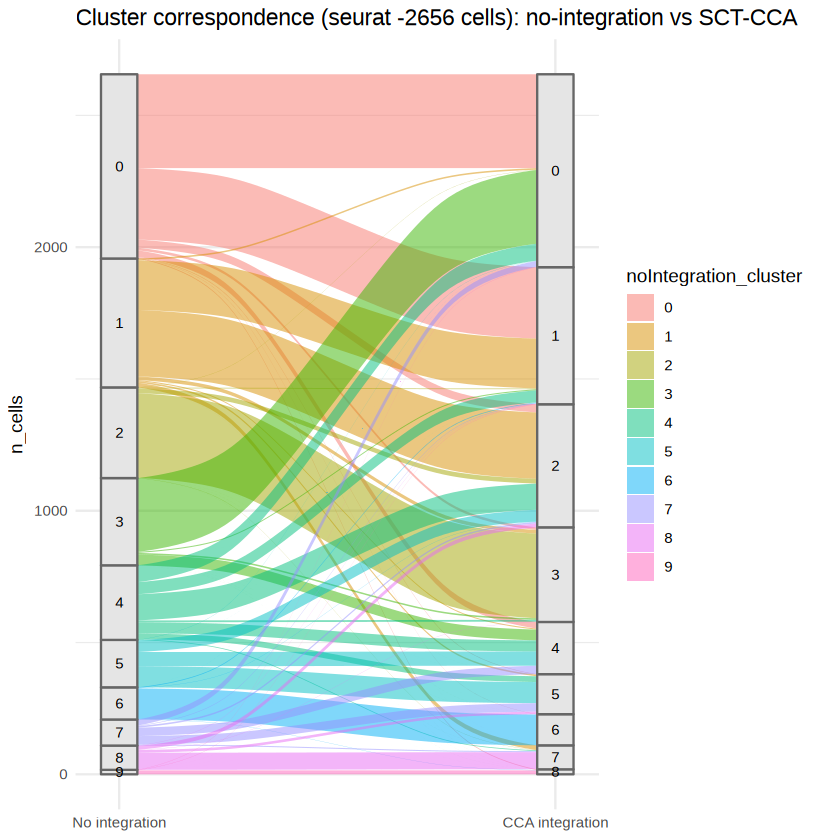

In [97]:
library(ggalluvial)

overlap_df <- as.data.frame(cluster_overlap_matrix)
colnames(overlap_df) <- c("noIntegration_cluster", "CCAintegration_cluster", "n_cells")

p_alluvial <- ggplot(
  overlap_df,
  aes(
    axis1 = noIntegration_cluster,
    axis2 = CCAintegration_cluster,
    y = n_cells
  )
) +
  geom_alluvium(aes(fill = noIntegration_cluster), width = 1/12) +
  geom_stratum(width = 1/12, fill = "grey90", color = "grey40") +
  geom_text(stat = "stratum", aes(label = after_stat(stratum)), size = 3) +
  scale_x_discrete(
    limits = c("No integration", "CCA integration"),
    expand = c(.05, .05)
  ) +
  theme_minimal() +
  ggtitle(paste0("Cluster correspondence (seurat -", ncol(seurat_noIntegration), " cells): no-integration vs SCT-CCA "))

p_alluvial

ggsave(
  filename = file.path(
    COMPARISON_DIR,
    "cluster_alluvial_noIntegration_vs_CCAintegration.png"
  ),
  plot = p_alluvial,
  width = 10,
  height = 7,
  dpi = 300
)

In [91]:
ncol(seurat_filtered)

[1] 2656

In [92]:
ncol(seurat_noIntegration)

[1] 2656

## 